**Recipe recommendation with two towers**

Only `new_dataset_recommendation_df`, loaded from `input_stage2/recipe_user_ratings.csv`,
is used. Run `map_recipe_nutrients.ipynb` first when rebuilding that CSV: each rating
must retain its original `RAW_interactions.csv` **date**.

The pipeline follows `two-tower-implementation.md`:

```text
ratings → split by rating: 4–5★ positive │ 1–2★ hard negative │ 3★ neutral
        → rows: one per positive (≤ 50 per user per epoch, resampled) + one sampled hard negative
        → batch + [B, 2B] mask: other positives and neutral recipes of the row's user, PAD
        → towers: user (ID embedding + GRU over dated history) → U; item (content + recipe ID) → I, H
        → loss: [U·Iᵀ | U·Hᵀ] / τ, − logQ on the in-batch block, + log w on the hard block, mask, cross-entropy
        → evaluate: Recall@K on held-out validation positives vs a popularity baseline
        → serve: precomputed item vectors → inner-product index (FAISS) → top K per user
```

The **item tower** combines content (ingredient, adjective and verb semantics, nutrition
clusters, price) with a learned **recipe-ID embedding** for recipes with enough ratings. The
**user tower** combines a **user-ID embedding** with a **GRU** over the user's earlier ratings
(recipe features, rating, level, age); attention favors recent ratings and gives neutral
ones half weight. Both towers are **L2-normalized**, so their dot product is the cosine
similarity. The two-tower only retrieves: rating predictions come from the LightGBM reranker
(`model_training_reranker.ipynb`), which uses the two-tower score as a feature.

Where this notebook differs from the guide, and why:
- **Validation split:** a stratified random 20% holdout of all ratings (the reranker trains on
  exactly this split), not a per-user holdout of positives. Recall@K uses the held-out
  positives of validation users who have training history.
- **User tower:** a user-ID embedding plus a GRU over dated history, not an ID-only tower.
- **PAD:** catalog index 0 is a real recipe, so an empty hard-negative slot is −1 in batches;
  row 0 of the recipe-ID embedding is the zero PAD row that rare recipes share.
- **logQ:** centered within each batch before it is subtracted from the in-batch block. The
  logQ correction only needs the differences between in-batch columns; uncentered, it would
  add about +10 to every in-batch logit and push the uncorrected hard-negative block out of
  the softmax.
- **Also kept:** rating-5 thinning, recency weights on training rows, and the date-aware
  history (each row sees only ratings from earlier days).

Unrated recipes remain candidates but never become training labels. A user absent from
training uses the unknown-user ID row together with whatever history they have.

In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install torch transformers==5.17.0 numpy pandas scikit-learn joblib matplotlib
import json
import random
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from IPython.display import display

**Configuration**

`RECENCY_HALF_LIFE_DAYS = 180` gives a rating half its history weight after 180 days.
`USER_ID_DIM` sizes the user-ID embedding, and `USER_ID_DROPOUT` is the share of training
rows whose user ID is hidden so the unknown-user slot learns a default.
Each missing price contributes **±$2**, so three null ingredients contribute ±$6 around
the sum of known prices (lower bound clipped at zero). This is an uncertainty feature,
not an imputed ingredient cost. The item tower receives both the known sum and the
uncertainty. Nested fuzzy-price dictionaries are summed recursively.

Nutrition columns retain the input CSV's existing names, units, and values. Each column
is averaged separately per recipe; a list-valued cell is reduced to its nonmissing mean.
Duplicate interaction rows do not multiply a recipe's weight in clustering. Median
imputation, missing indicators, `log1p`, and scaling precede nutrition-only clustering.
Every recipe has a cluster; candidates are not restricted to the user's prior clusters.

The training settings follow `two-tower-implementation.md`: `BATCH_SIZE = 512`,
`IN_BATCH_TEMPERATURE = 0.05` (τ; tune within 0.02–0.2), `HARD_NEGATIVE_WEIGHT = 1.0` (w; try
2–5 if dislikes are informative), `EMBEDDING_DIM = 64`, and `MAX_ROWS_PER_USER = 50`.
`NORMALIZE_EMBEDDINGS = True` L2-normalizes both towers, so their dot product is the cosine
similarity; with `False` the score is the raw dot product, and τ around 1.0 suits it better.
`ITEM_ID_DIM`, `ITEM_ID_DROPOUT` and `MIN_ITEM_RATINGS_FOR_ID` control the recipe-ID embedding,
and `RECALL_KS` and `RECALL_SAMPLE_USERS` control Recall@K. `NUM_WORKERS` is 2 on Linux (Colab,
Kaggle) and 0 on macOS and Windows, where DataLoader workers can't load classes defined in a
notebook. `NEUTRAL_HISTORY_WEIGHT`, the stratified split, and the rating-5 thinning limits are
explained with training below.

In [2]:
RANDOM_STATE = 42
BERT_MODEL = "bert-base-uncased"
BERT_REVISION = "86b5e0934494bd15c9632b12f734a8a67f723594"
BERT_BATCH_SIZE = 64
BERT_MAX_LENGTH = 64
SEMANTIC_DIM_PER_FIELD = 128
NUTRITION_CLUSTERS = 32
MISSING_PRICE_ERROR_DOLLARS = 2.0
RECENCY_HALF_LIFE_DAYS = 180.0
MAX_HISTORY = 64
VALIDATION_FRACTION = 0.2
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
USER_ID_DIM = 32
USER_ID_DROPOUT = 0.1
ITEM_ID_DIM = 32
ITEM_ID_DROPOUT = 0.1
MIN_ITEM_RATINGS_FOR_ID = 5  # Rarer recipes share the zero PAD row and rely on content alone.
NORMALIZE_EMBEDDINGS = True  # L2-normalized towers: the dot product is the cosine similarity.
EPOCHS = 20
BATCH_SIZE = 512  # Larger batches mean more in-batch negatives.
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 4
IN_BATCH_TEMPERATURE = 0.05  # tau: tune within 0.02-0.2 (about 1.0 without normalization).
HARD_NEGATIVE_WEIGHT = 1.0  # w: log(w) is added to hard-negative logits; try 2-5 if dislikes are informative.
MAX_ROWS_PER_USER = 50  # Per-epoch cap on a user's training rows, resampled every epoch.
RECALL_KS = (20, 100, 200)
RECALL_SAMPLE_USERS = 10_000  # Users scored for Recall@K after each epoch; the final report uses all.
# DataLoader workers need fork (Linux: Colab, Kaggle); macOS and Windows can't load notebook classes in them.
NUM_WORKERS = 2 if sys.platform.startswith("linux") else 0
NEUTRAL_HISTORY_WEIGHT = 0.5  # A neutral (3) history rating starts at half the attention weight.
MAX_FIVE_STAR_TARGETS_PER_USER = 5
MAX_FIVE_TO_OTHER_RATIO = 1.0

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
# CUDA first, then Apple-silicon MPS, then CPU.
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("GPU: Apple silicon (MPS)")
else:
    import warnings
    warnings.warn(f"No GPU visible (torch {torch.__version__}, built for CUDA {torch.version.cuda}); training on "
                  "the CPU. On Colab: Runtime > Change runtime type > GPU. On Kaggle: Settings > Accelerator > "
                  "GPU. If CUDA is None there, a CPU-only torch was installed.", stacklevel=1)
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root; restore recipe_user_ratings.csv.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
ARTIFACT_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower"
CACHE_DIR = NOTEBOOK_DIR / "output/two_tower_cache"
print(f"Device: {device}; recipe data: {DATA_PATH}")

GPU: Apple silicon (MPS)
Device: mps; recipe data: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv


**Self-contained model and data definitions**

The following two cells contain parsing, feature construction, both towers, chronological
history assembly, training, and prediction. No local model module is required.

In [3]:
"""Two-tower retrieval model following two-tower-implementation.md (GRU user tower, content + ID items)."""
import copy
import math
import sys
import warnings
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, default_collate

NUM_RATING_CLASSES = 5  # Ratings 1..5 are ordinal classes 0..4.
LEVEL_NAMES = ("negative", "neutral", "positive")  # Ratings 1-2, 3, and 4-5.
NEGATIVE, NEUTRAL, POSITIVE = range(len(LEVEL_NAMES))
RATING_CLASS_LEVELS = np.array([NEGATIVE, NEGATIVE, NEUTRAL, POSITIVE, POSITIVE])
PAD_ITEM = -1  # Hard-negative slot for a user with no 1-2 star recipe (catalog index 0 is a real recipe).
# Roles of the cells in a [B, 2B] logits grid; codes from ROLE_LIKED up are masked to -inf.
BATCH_ROLES = ("N", "HN", "P", "mask: liked", "mask: neutral", "mask: PAD")
ROLE_N, ROLE_HN, ROLE_P, ROLE_LIKED, ROLE_NEUTRAL, ROLE_PAD = range(len(BATCH_ROLES))


def canonical_id(value):
    """Normalize integer IDs loaded as numbers, strings, or CSV float strings."""
    if value is None or pd.isna(value):
        return None
    value = str(value).strip()
    if value.lower() in {"", "nan", "none", "null", "<na>"}:
        return None
    try:
        number = Decimal(value)
        if not number.is_finite():
            return None
        if number == number.to_integral_value():
            return str(int(number))
    except InvalidOperation:
        pass
    return value


def build_interactions(df, catalog):
    required = {"recipe_id", "user_id", "rating", "date"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing interaction columns {sorted(missing)}. Rerun map_recipe_nutrients.ipynb to export the original rating date.")
    catalog_ids = catalog["recipe_id"].map(canonical_id)
    if catalog_ids.isna().any() or catalog_ids.duplicated().any():
        raise ValueError("Catalog recipe_id values must be valid and unique after ID normalization.")
    frame = df.loc[:, ["recipe_id", "user_id", "rating", "date"]].copy()
    ratings = pd.to_numeric(frame["rating"], errors="coerce")
    malformed = frame["rating"].notna() & ratings.isna()
    invalid = ratings.notna() & ratings.ne(0) & ~ratings.between(1, 5)
    if malformed.any() or invalid.any():
        raise ValueError("Ratings must be numeric values from 1 to 5; use 0 or null for unlabeled rows.")
    frame["rating"] = ratings
    frame = frame.loc[ratings.between(1, 5)].copy()
    frame["user_id"] = frame["user_id"].map(canonical_id)
    frame["recipe_id"] = frame["recipe_id"].map(canonical_id)
    valid_ids = frame["user_id"].notna() & frame["recipe_id"].isin(set(catalog_ids))
    if (~valid_ids).any():
        warnings.warn(f"Excluded {(~valid_ids).sum():,} labeled rows with missing user IDs or recipes absent from the catalog.", stacklevel=2)
    frame = frame.loc[valid_ids].copy()
    frame["date"] = pd.to_datetime(frame["date"], format="mixed", errors="coerce", utc=True)
    if frame["date"].isna().any():
        raise ValueError("Labeled interactions contain missing/invalid dates. Rerun map_recipe_nutrients.ipynb and regenerate the mapped CSV with original dates; do not invent timestamps.")
    item_lookup = dict(zip(catalog_ids, range(len(catalog_ids))))
    frame["item_index"] = frame["recipe_id"].map(item_lookup).astype("int64")
    frame = frame.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
    frame["level"] = np.asarray(LEVEL_NAMES)[rating_to_level(frame["rating"])]
    return frame[["user_id", "item_index", "rating", "level", "date"]].reset_index(drop=True)


def stratified_split(interactions, validation_fraction=0.2, seed=42):
    """Random holdout stratified on the rating, so both splits keep the same class shares."""
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must lie between 0 and 1.")
    train, validation = train_test_split(interactions, test_size=validation_fraction,
                                         stratify=interactions["rating"], random_state=seed)
    order = ["user_id", "date"]
    return (train.sort_values(order, kind="stable").reset_index(drop=True),
            validation.sort_values(order, kind="stable").reset_index(drop=True))


def downsample_five_star_targets(targets, max_five_star=5, max_five_to_other_ratio=1.0, seed=42):
    """Randomly thin rating-5 targets of users who already have many of them.

    Each rating-5 row survives with probability min(1, limit / user's 5s), where
    limit = max(max_five_star, ratio * user's other ratings). Users under the limit are
    untouched; with ratio 1, a thinned user keeps about as many 5s as other ratings.
    """
    if max_five_star < 1 or not np.isfinite(max_five_to_other_ratio) or max_five_to_other_ratio < 0:
        raise ValueError("Use max_five_star >= 1 and a finite, nonnegative max_five_to_other_ratio.")
    five = targets["rating"].eq(5)
    per_user = five.groupby(targets["user_id"]).agg(["sum", "size"])
    limit = np.maximum(max_five_star, max_five_to_other_ratio * (per_user["size"] - per_user["sum"]))
    user_keep = (limit / per_user["sum"].clip(lower=1)).clip(upper=1.0)
    keep_probability = np.where(five, targets["user_id"].map(user_keep), 1.0)
    keep = np.random.default_rng(seed).random(len(targets)) < keep_probability
    return targets.loc[keep].reset_index(drop=True)


def rating_classes(ratings):
    """Map integer ratings 1..5 to ordinal class indices 0..4."""
    values = np.asarray(ratings, dtype=np.float64)
    classes = np.rint(values) - 1
    if not np.isin(classes, np.arange(NUM_RATING_CLASSES)).all() or not np.array_equal(values, classes + 1):
        raise ValueError("Rating classes require integer ratings from 1 to 5.")
    return classes.astype(np.int64)


def rating_to_level(ratings):
    """Level index per rating: 0 negative (1-2), 1 neutral (3), 2 positive (4-5)."""
    return RATING_CLASS_LEVELS[rating_classes(ratings)]


def _isin_sorted(values, sorted_keys):
    """Elementwise membership of integer values in a sorted, unique integer array."""
    values = np.asarray(values)
    if not len(sorted_keys):
        return np.zeros(values.shape, dtype=bool)
    positions = np.searchsorted(sorted_keys, values).clip(max=len(sorted_keys) - 1)
    return sorted_keys[positions] == values


def build_item_id_rows(positive_items, num_items, min_ratings=5):
    """Recipe-ID embedding row for every catalog recipe, and how many recipes get their own row.

    Recipes with at least min_ratings training positives get rows 1..n; all others share
    row 0, the zero PAD row, and rely on their content features alone.
    """
    if min_ratings < 1:
        raise ValueError("min_ratings must be positive.")
    counts = np.bincount(np.asarray(positive_items, dtype=np.int64), minlength=num_items)[:num_items]
    kept = np.flatnonzero(counts >= min_ratings)
    rows = np.zeros(num_items, dtype=np.int64)
    rows[kept] = np.arange(1, len(kept) + 1)
    return rows, len(kept)


class HistoryIndex:
    """Each user's ratings sorted by date: (dates in ns, item indices, rating classes 0..4)."""
    def __init__(self, history):
        frame = history.sort_values("date", kind="stable")
        dates = frame["date"].astype("int64").to_numpy()
        items = frame["item_index"].to_numpy(dtype=np.int64)
        classes = rating_classes(frame["rating"])
        self.users = {canonical_id(user): (dates[positions], items[positions], classes[positions])
                      for user, positions in frame.groupby("user_id", sort=False).indices.items()}


def _utc_day(value):
    stamp = pd.Timestamp(value)
    if pd.isna(stamp):
        raise ValueError("A valid as_of/reference_date is required.")
    return (stamp.tz_localize("UTC") if stamp.tzinfo is None else stamp.tz_convert("UTC")).floor("D")


def user_history(index, user_id, as_of, max_history=64, exclude_item=None):
    """Up to max_history ratings from UTC days strictly before as_of, oldest first.

    Returns item indices, rating classes 0..4, and each rating's age in days at as_of's day.
    exclude_item (one recipe index or several) is left out, e.g. a target and its contrast.
    """
    if max_history < 1:
        raise ValueError("max_history must be positive.")
    cutoff = int(as_of) if isinstance(as_of, (int, np.integer)) else _utc_day(as_of).value
    records = index.users.get(canonical_id(user_id))
    if records is None:
        return np.empty(0, np.int64), np.empty(0, np.int64), np.empty(0, np.float32)
    dates, items, classes = records
    end = np.searchsorted(dates, cutoff, side="left")
    excluded = np.atleast_1d(np.asarray([] if exclude_item is None else exclude_item, dtype=np.int64))
    # A user rates each recipe once, so one spare row per excluded recipe keeps max_history rows.
    selected = np.arange(max(0, end - max_history - len(excluded)), end)
    selected = selected[~np.isin(items[selected], excluded)][-max_history:]
    age_days = ((cutoff - dates[selected]) / (86400 * 1e9)).astype(np.float32)
    return items[selected], classes[selected], age_days


def pad_history(items, classes, age_days, max_history=64):
    """Right-pad one history to max_history steps; history_mask marks real ratings."""
    padded = {"history_items": np.zeros(max_history, np.int64), "history_ratings": np.zeros(max_history, np.int64),
              "history_age_days": np.zeros(max_history, np.float32), "history_mask": np.zeros(max_history, bool)}
    length = len(items)
    for key, values in [("history_items", items), ("history_ratings", classes), ("history_age_days", age_days)]:
        padded[key][:length] = values
    padded["history_mask"][:length] = True
    return {key: torch.from_numpy(value) for key, value in padded.items()}


def build_user_lookup(history):
    """User-ID vocabulary from training ratings: 1..n per user; 0 is the unknown user."""
    users = sorted(history["user_id"].map(canonical_id).dropna().unique())
    return {user: index for index, user in enumerate(users, start=1)}


def _feature_tensor(item_features, device):
    """Item features on the compute device, copied once so per-batch gathers stay there."""
    if torch.is_tensor(item_features):
        return item_features.to(device=device, dtype=torch.float32)
    return torch.as_tensor(np.asarray(item_features, dtype=np.float32)).to(device)


def user_inputs(batch, features, device):
    """User-tower tensors for one batch, trimmed to its longest history."""
    width = max(1, int(batch["history_mask"].sum(dim=1).max()))
    history_items = batch["history_items"][:, :width]
    return (batch["user_index"].to(device), features[history_items.to(features.device)].to(device),
            batch["history_ratings"][:, :width].to(device), batch["history_age_days"][:, :width].to(device),
            batch["history_mask"][:, :width].to(device))


class HistoryDataset(Dataset):
    """One row per target rating, with the user's strictly earlier ratings as a dated sequence.

    A positive target also carries one random same-user 1-2 star recipe from contrast_pool
    (default: the targets) as its hard negative: redrawn on every read in training, fixed in
    validation, and hidden from the row's history like the target itself. resample() picks
    each epoch's rows (at most max_per_user per user), and collate() batches rows together
    with the [B, 2B] mask of the in-batch softmax.
    """
    def __init__(self, targets, history, user_lookup=None, max_history=64, half_life_days=180,
                 training=True, reference_date=None, weight_floor=0.1, contrast_pool=None, seed=42):
        self.targets = targets.reset_index(drop=True).copy()
        self.history_index = HistoryIndex(history)
        self.max_history, self.half_life_days = max_history, half_life_days
        if max_history < 1 or half_life_days <= 0 or not 0 < weight_floor <= 1:
            raise ValueError("Use max_history >= 1, half_life_days > 0, and 0 < weight_floor <= 1.")
        self.rating_classes = rating_classes(self.targets["rating"])
        lookup = user_lookup or {}
        self.user_indices = np.array([lookup.get(user, 0) for user in self.targets["user_id"]], dtype=np.int64)
        self.cutoffs = self.targets["date"].dt.floor("D").astype("int64").to_numpy()
        self.weights = np.ones(len(self.targets), dtype=np.float32)
        if training and len(self.targets):
            reference = history["date"].max() if reference_date is None else reference_date
            reference = _utc_day(reference)
            age = (reference - self.targets["date"].dt.floor("D")).dt.total_seconds().to_numpy() / 86400
            self.weights = np.maximum(weight_floor, np.exp2(-np.maximum(age, 0) / half_life_days)).astype(np.float32)
        self.target_levels = RATING_CLASS_LEVELS[self.rating_classes]
        pool = self.targets if contrast_pool is None else contrast_pool
        pool_items, pool_levels = pool["item_index"].to_numpy(dtype=np.int64), rating_to_level(pool["rating"])
        # Per user: (negative recipes, positive recipes) to contrast against.
        self.level_items = {user: (pool_items[positions][pool_levels[positions] == NEGATIVE],
                                   pool_items[positions][pool_levels[positions] == POSITIVE])
                            for user, positions in pool.groupby("user_id", sort=False).indices.items()}
        self.has_contrast = np.array([len(self._options(level, user)) > 0 for user, level
                                      in zip(self.targets["user_id"], self.target_levels)], dtype=bool)
        self.rng = np.random.default_rng(seed)
        # Validation pairs stay fixed, so every epoch is scored on the same comparisons.
        self.fixed_contrasts = None if training else [
            self._contrast(level, user, self.rng) for user, level in zip(self.targets["user_id"], self.target_levels)]
        self.active = np.arange(len(self.targets))  # This epoch's rows; see resample().
        # The mask's (user, recipe) keys are built on first use from every rating this dataset sees.
        self._mask_frames = [frame for frame in (history, contrast_pool) if frame is not None] + [self.targets]
        self._mask_sets = None

    def _options(self, level, user):
        """Recipes of the opposite level from the same user; none for a neutral target."""
        if level == NEUTRAL:
            return ()
        negatives, positives = self.level_items.get(user, ((), ()))
        return negatives if level == POSITIVE else positives

    def _contrast(self, level, user, rng):
        """(contrast recipe, sign): +1 when the target should outscore it, -1 when it should lose."""
        options = self._options(level, user)
        if not len(options):
            return 0, 0.0
        return int(options[rng.integers(len(options))]), (1.0 if level == POSITIVE else -1.0)

    @property
    def mask_sets(self):
        """Sorted (user, recipe) keys of every positive and neutral rating in history, pool and targets."""
        if self._mask_sets is None:
            ratings = pd.concat([frame[["user_id", "item_index", "rating"]] for frame in self._mask_frames],
                                ignore_index=True)
            codes, users = pd.factorize(ratings["user_id"])
            stride = int(ratings["item_index"].max()) + 1 if len(ratings) else 1
            keys = codes.astype(np.int64) * stride + ratings["item_index"].to_numpy(dtype=np.int64)
            levels = rating_to_level(ratings["rating"])
            self._mask_sets = {"stride": stride,
                               "row_codes": pd.Index(users).get_indexer(self.targets["user_id"]).astype(np.int64),
                               "positive_keys": np.unique(keys[levels == POSITIVE]),
                               "neutral_keys": np.unique(keys[levels == NEUTRAL])}
        return self._mask_sets

    def resample(self, max_per_user=None, seed=None):
        """Choose this epoch's rows: all of them, or at most max_per_user random rows per user."""
        if max_per_user is None:
            self.active = np.arange(len(self.targets))
            return self
        if max_per_user < 1:
            raise ValueError("max_per_user must be positive.")
        order = np.random.default_rng(seed).permutation(len(self.targets))
        users = self.targets["user_id"].to_numpy()[order]
        rank = pd.Series(users).groupby(users, sort=False).cumcount().to_numpy()
        self.active = np.sort(order[rank < max_per_user])
        return self

    def batch_roles(self, rows, positives, hard):
        """Role of every cell in the [B, 2B] logits grid, as codes into BATCH_ROLES.

        Columns are [the batch's positives, its hard negatives]. For each row, a column holding
        another positive or a neutral (3 star) recipe of that row's user is masked (neither
        positive nor negative), and so is every PAD column. The row's own positive (the
        diagonal) and the user's own dislikes are never masked.
        """
        sets = self.mask_sets
        positives, hard = np.asarray(positives, dtype=np.int64), np.asarray(hard, dtype=np.int64)
        size = len(positives)
        columns = np.concatenate([positives, hard])
        keys = (sets["row_codes"][np.asarray(rows, dtype=np.int64)][:, None] * sets["stride"]
                + np.maximum(columns, 0)[None, :])
        roles = np.full((size, 2 * size), ROLE_N, dtype=np.int8)
        roles[:, size:] = ROLE_HN
        roles[_isin_sorted(keys, sets["neutral_keys"])] = ROLE_NEUTRAL
        roles[_isin_sorted(keys, sets["positive_keys"])] = ROLE_LIKED
        roles[:, columns == PAD_ITEM] = ROLE_PAD
        roles[np.arange(size), np.arange(size)] = ROLE_P
        return roles

    def collate(self, samples):
        """Default batching, plus each row's hard negative (PAD if none) and the [B, 2B] mask."""
        batch = default_collate(samples)
        batch["hard_item_index"] = torch.where(batch["contrast_sign"] > 0, batch["contrast_item_index"],
                                               torch.full_like(batch["item_index"], PAD_ITEM))
        roles = self.batch_roles(batch["row"].numpy(), batch["item_index"].numpy(), batch["hard_item_index"].numpy())
        batch["mask"] = torch.from_numpy(roles >= ROLE_LIKED)
        return batch

    def __len__(self):
        return len(self.active)

    def __getitem__(self, index):
        position = int(self.active[index])
        row = self.targets.iloc[position]
        contrast_item, contrast_sign = (self.fixed_contrasts[position] if self.fixed_contrasts is not None
                                        else self._contrast(self.target_levels[position], row.user_id, self.rng))
        # Serving candidates are unrated, so neither recipe of a pair may be read from the history.
        hidden = (row.item_index, contrast_item) if contrast_sign else row.item_index
        sample = pad_history(*user_history(self.history_index, row.user_id, int(self.cutoffs[position]),
                                           self.max_history, exclude_item=hidden), self.max_history)
        sample.update({"user_index": int(self.user_indices[position]), "item_index": int(row.item_index),
                       "rating": torch.tensor(row.rating, dtype=torch.float32),
                       "sample_weight": torch.tensor(self.weights[position], dtype=torch.float32),
                       "contrast_item_index": contrast_item,
                       "contrast_sign": torch.tensor(contrast_sign, dtype=torch.float32), "row": position})
        return sample


def _seed_worker(worker_id):
    """Give each DataLoader worker its own hard-negative random stream."""
    info = torch.utils.data.get_worker_info()
    info.dataset.rng = np.random.default_rng(info.seed % 2**32)


class TwoTowerModel(nn.Module):
    """GRU user tower and content + recipe-ID item tower; the score is their dot product.

    With normalize=True (the guide's default) both towers output unit vectors, so the dot
    product is the cosine similarity. The model retrieves; it never predicts a rating.
    """
    def __init__(self, feature_dim, num_users, embedding_dim=64, hidden_dim=128, user_id_dim=32,
                 half_life_days=180.0, user_id_dropout=0.1, rating_dim=16, neutral_weight=0.5,
                 num_items=0, num_item_ids=0, item_id_dim=0, item_id_dropout=0.1, normalize=True):
        super().__init__()
        if (half_life_days <= 0 or neutral_weight <= 0 or not 0 <= user_id_dropout < 1
                or not 0 <= item_id_dropout < 1):
            raise ValueError("Use half_life_days > 0, neutral_weight > 0, and dropouts in [0, 1).")
        use_item_ids = item_id_dim > 0 and num_item_ids > 0
        if use_item_ids and num_items < 1:
            raise ValueError("Recipe-ID embeddings need num_items, the catalog size.")
        self.config = {"feature_dim": feature_dim, "num_users": num_users, "embedding_dim": embedding_dim,
                       "hidden_dim": hidden_dim, "user_id_dim": user_id_dim, "half_life_days": float(half_life_days),
                       "user_id_dropout": float(user_id_dropout), "rating_dim": rating_dim,
                       "neutral_weight": float(neutral_weight), "num_items": num_items,
                       "num_item_ids": num_item_ids if use_item_ids else 0,
                       "item_id_dim": item_id_dim if use_item_ids else 0,
                       "item_id_dropout": float(item_id_dropout), "normalize": bool(normalize)}
        # Row 0 is the zero PAD row: recipes with too few ratings rely on their content alone.
        self.item_embedding = nn.Embedding(num_item_ids + 1, item_id_dim, padding_idx=0) if use_item_ids else None
        if use_item_ids:
            self.register_buffer("item_id_rows", torch.zeros(num_items, dtype=torch.long))
        self.item_tower = nn.Sequential(nn.Linear(feature_dim + self.config["item_id_dim"], hidden_dim),
                                        nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))
        # Row 0 is the unknown user; ID dropout trains it for users absent from training.
        self.user_embedding = nn.Embedding(num_users + 1, user_id_dim)
        self.history_projection = nn.Sequential(nn.Linear(feature_dim, hidden_dim), nn.ReLU())
        self.rating_embedding = nn.Embedding(NUM_RATING_CLASSES, rating_dim)
        self.history_rnn = nn.GRU(hidden_dim + rating_dim + len(LEVEL_NAMES) + 1, hidden_dim, batch_first=True)
        self.history_attention = nn.Linear(hidden_dim, 1)
        # Each rating class's level, and each level's log attention prior (neutral starts lower).
        self.register_buffer("rating_level", torch.as_tensor(RATING_CLASS_LEVELS), persistent=False)
        level_weights = torch.ones(len(LEVEL_NAMES))
        level_weights[NEUTRAL] = neutral_weight
        self.register_buffer("level_log_weight", level_weights.log(), persistent=False)
        self.user_head = nn.Sequential(nn.Linear(2 * hidden_dim + 2 + user_id_dim, hidden_dim),
                                       nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))

    def set_item_id_rows(self, rows):
        """Map catalog recipe index -> recipe-ID embedding row (see build_item_id_rows)."""
        if self.item_embedding is None:
            raise ValueError("This model has no recipe-ID embeddings.")
        rows = torch.as_tensor(np.asarray(rows), dtype=torch.long)
        if rows.shape != self.item_id_rows.shape or rows.min() < 0 or rows.max() > self.config["num_item_ids"]:
            raise ValueError("rows must map every catalog recipe to 0..num_item_ids.")
        self.item_id_rows.copy_(rows.to(self.item_id_rows.device))
        return self

    def _output(self, vectors):
        return F.normalize(vectors, dim=-1) if self.config["normalize"] else vectors

    def encode_items(self, features, item_index=None):
        """Item vectors from content features and, when the model has them, recipe-ID embeddings."""
        if self.item_embedding is not None:
            if item_index is None:
                raise ValueError("This model has recipe-ID embeddings: pass item_index with the features.")
            rows = self.item_id_rows[item_index]
            if self.training and self.config["item_id_dropout"] > 0:
                # Randomly fall back to content only, so recipes without an ID row train well too.
                hidden = torch.rand(rows.shape, device=rows.device) < self.config["item_id_dropout"]
                rows = rows.masked_fill(hidden, 0)
            features = torch.cat([features, self.item_embedding(rows)], dim=-1)
        return self._output(self.item_tower(features))

    def history_weights(self, outputs, history_age_days, history_ratings, history_mask):
        """Attention over history steps with two priors before learning adjusts them.

        A rating one half-life older gets half the weight, and a neutral rating gets
        neutral_weight (0.5) of a positive or negative rating's weight.
        """
        scores = self.history_attention(outputs).squeeze(-1)
        scores = scores - history_age_days * (math.log(2) / self.config["half_life_days"])
        scores = scores + self.level_log_weight[self.rating_level[history_ratings]]
        return torch.softmax(scores.masked_fill(~history_mask, -1e4), dim=1)

    def encode_users(self, user_index, history_features, history_ratings, history_age_days, history_mask):
        """GRU over past ratings and levels (oldest first), weighted attention, and a user-ID embedding."""
        if self.training and self.config["user_id_dropout"] > 0:
            hidden = torch.rand(user_index.shape, device=user_index.device) < self.config["user_id_dropout"]
            user_index = user_index.masked_fill(hidden, 0)
        lengths = history_mask.sum(dim=1)
        has_history = (lengths > 0).unsqueeze(-1).to(history_features.dtype)
        levels = F.one_hot(self.rating_level[history_ratings], len(LEVEL_NAMES)).to(history_features.dtype)
        steps = torch.cat([self.history_projection(history_features), self.rating_embedding(history_ratings),
                           levels, torch.log1p(history_age_days).unsqueeze(-1)], dim=-1)
        outputs, _ = self.history_rnn(steps)
        # Right padding comes after every real step, so the GRU state at length - 1 is the latest rating's.
        last = outputs[torch.arange(len(outputs), device=outputs.device), (lengths - 1).clamp_min(0)]
        weights = self.history_weights(outputs, history_age_days, history_ratings, history_mask)
        pooled = (weights.unsqueeze(-1) * outputs).sum(dim=1)
        summary = torch.cat([last * has_history, pooled * has_history, has_history,
                             torch.log1p(lengths.to(history_features.dtype)).unsqueeze(-1),
                             self.user_embedding(user_index)], dim=-1)
        return self._output(self.user_head(summary))

    def similarity(self, users, items):
        """Dot product of tower vectors (the cosine similarity when the towers are normalized)."""
        return (users * items).sum(dim=-1)

    def forward(self, user_index, history_features, history_ratings, history_age_days, history_mask,
                item_features, item_index=None):
        """Two-tower score of each (user, history, item) row; higher means a closer match."""
        users = self.encode_users(user_index, history_features, history_ratings, history_age_days, history_mask)
        return self.similarity(users, self.encode_items(item_features, item_index))


def positive_rows(frame):
    """Training rows are liked (4-5 star) ratings only; neutral and negative rows are dropped."""
    return frame.loc[rating_to_level(frame["rating"]) == POSITIVE].reset_index(drop=True)


def batch_softmax_losses(model, users, items, batch, features, log_q, temperature=0.05, hard_negative_weight=1.0):
    """In-batch softmax with hard negatives (two-tower-implementation.md, section 5).

    logits = [U·Iᵀ | U·Hᵀ] / τ: the batch's positives I, then each row's hard negative H
    (PAD if none); row i's label is column i. The in-batch block subtracts log q (logQ
    correction), centered within the batch so it doesn't shift that block against the
    hard-negative block, which adds log(hard_negative_weight). Cells in batch["mask"] (from
    HistoryDataset.collate) become -inf. Returns per-row CE, which rows have a hard negative,
    and whether each row's positive outscored its own hard negative (raw scores).
    """
    device = items.device
    size = len(items)
    positive_ids = batch["item_index"].to(device)
    if "hard_item_index" in batch:
        hard_ids = batch["hard_item_index"].to(device)
    else:
        hard_ids = torch.where(batch["contrast_sign"].to(device) > 0, batch["contrast_item_index"].to(device),
                               torch.full_like(positive_ids, PAD_ITEM))
    has_hard = hard_ids != PAD_ITEM
    hard_safe = hard_ids.clamp_min(0)
    hard = model.encode_items(features[hard_safe], hard_safe)
    scores = users @ torch.cat([items, hard]).T  # Dot products, as in model.similarity.
    in_batch_q = log_q[positive_ids]
    logits = torch.cat([scores[:, :size] / temperature - (in_batch_q - in_batch_q.mean()),
                        scores[:, size:] / temperature + math.log(hard_negative_weight)], dim=1)
    if "mask" in batch:
        mask = batch["mask"].to(device)
    else:  # Without HistoryDataset.collate: mask my recipe elsewhere, my other rows, and PAD.
        all_ids = torch.cat([positive_ids, hard_ids])
        mask = positive_ids.unsqueeze(1) == all_ids.unsqueeze(0)
        user_index = batch["user_index"].to(device)
        mask[:, :size] |= (user_index.unsqueeze(1) == user_index.unsqueeze(0)) & (user_index > 0).unsqueeze(1)
        mask &= ~torch.eye(size, 2 * size, dtype=torch.bool, device=device)
        mask |= (all_ids == PAD_ITEM).unsqueeze(0)
    logits = logits.masked_fill(mask, float("-inf"))
    labels = torch.arange(size, device=device)
    wins = scores[labels, labels] > scores[labels, labels + size]
    return F.cross_entropy(logits, labels, reduction="none"), has_hard, wins


@torch.no_grad()
def evaluate_two_tower(model, dataset, item_features, batch_size=512, device=None, log_q=None,
                       temperature=0.05, hard_negative_weight=1.0):
    """Mean in-batch softmax CE over one pass, plus how often a positive beats its hard negative."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    features = _feature_tensor(item_features, device)
    if log_q is None:
        log_q = torch.zeros(len(features), device=device)
    loss_total, rows, hard_rows, hard_wins = 0.0, 0, 0, 0
    # Rows are sorted by user; a fixed shuffle mixes users like training does, same every epoch.
    order = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(0)).tolist()
    model.eval()
    for batch in DataLoader(dataset, batch_size=batch_size, sampler=order, collate_fn=getattr(dataset, "collate", None)):
        item_ids = batch["item_index"].to(device)
        users = model.encode_users(*user_inputs(batch, features, device))
        items = model.encode_items(features[item_ids], item_ids)
        losses, has_hard, wins = batch_softmax_losses(model, users, items, batch, features, log_q, temperature,
                                                      hard_negative_weight)
        loss_total, rows = loss_total + float(losses.sum()), rows + len(losses)
        hard_rows, hard_wins = hard_rows + int(has_hard.sum()), hard_wins + int((wins & has_hard).sum())
    return {"in_batch_cross_entropy": loss_total / rows if rows else float("nan"), "in_batch_rows": rows,
            "hard_negative_rows": hard_rows,
            "hard_negative_accuracy": hard_wins / hard_rows if hard_rows else float("nan")}


class RecallAtK:
    """Recall@K on held-out positives, the guide's retrieval metric (section 7).

    Evaluated users have held-out positives and at least one training rating. Each is embedded
    from all their training ratings, as of the day after the last one, and recipes they rated
    in training (any rating) are never recommended. Recall@K = held-out positives found in the
    top K / all held-out positives of the evaluated users (micro average).
    """
    def __init__(self, history, heldout, user_lookup, num_items, ks=(20, 100, 200), max_history=64,
                 sample_users=None, seed=42):
        if not ks or min(ks) < 1:
            raise ValueError("ks must be positive.")
        self.ks, self.num_items = tuple(sorted(set(ks))), num_items
        index = HistoryIndex(history)
        heldout_items = heldout.groupby("user_id")["item_index"].apply(lambda items: items.to_numpy(np.int64))
        users = [user for user in heldout_items.index if canonical_id(user) in index.users]
        if sample_users is not None and len(users) > sample_users:
            users = sorted(np.random.default_rng(seed).choice(users, sample_users, replace=False).tolist())
        cutoff = (_utc_day(history["date"].max()) + pd.Timedelta(1, unit="D")).value if len(history) else 0
        padded = [pad_history(*user_history(index, user, cutoff, max_history), max_history) for user in users]
        keys = ("history_items", "history_ratings", "history_age_days", "history_mask")
        self.inputs = {key: torch.stack([sample[key] for sample in padded]) for key in keys} if padded else {}
        self.inputs["user_index"] = torch.tensor([(user_lookup or {}).get(user, 0) for user in users], dtype=torch.long)
        self.seen = [index.users[canonical_id(user)][1] for user in users]
        self.targets = [heldout_items[user] for user in users]
        self.users = users

    def _recall(self, scores_for, device, batch_users):
        """Micro Recall@K, given scores_for(start, end) -> [users, recipes] scores on device."""
        total = int(sum(len(targets) for targets in self.targets))
        hits = np.zeros(len(self.ks))
        top_k = min(self.ks[-1], self.num_items)
        for start in range(0, len(self.users), batch_users):
            end = min(start + batch_users, len(self.users))
            scores = scores_for(start, end)
            seen, targets = self.seen[start:end], self.targets[start:end]
            seen_rows = np.repeat(np.arange(end - start), [len(items) for items in seen])
            scores[torch.as_tensor(seen_rows, device=device),
                   torch.as_tensor(np.concatenate(seen), device=device)] = -torch.inf
            wanted = torch.zeros(scores.shape, dtype=torch.bool, device=device)
            target_rows = np.repeat(np.arange(end - start), [len(items) for items in targets])
            wanted[torch.as_tensor(target_rows, device=device),
                   torch.as_tensor(np.concatenate(targets), device=device)] = True
            found = wanted.gather(1, scores.topk(top_k, dim=1).indices).cpu().numpy()
            hits += [found[:, :k].sum() for k in self.ks]
        result = {f"recall@{k}": hit / total if total else float("nan") for k, hit in zip(self.ks, hits)}
        result.update(users=len(self.users), heldout_positives=total)
        return result

    @torch.no_grad()
    def evaluate(self, model, item_features, device=None, batch_users=256):
        """Recall@K of the two-tower model."""
        device = torch.device(device) if device is not None else next(model.parameters()).device
        model.eval()
        features = _feature_tensor(item_features, device)
        item_vectors = encode_catalog(model, features, device=device).to(device)

        def scores_for(start, end):
            batch = {key: value[start:end] for key, value in self.inputs.items()}
            return model.encode_users(*user_inputs(batch, features, device)) @ item_vectors.T

        return self._recall(scores_for, device, batch_users)

    def popularity(self, item_scores, device="cpu", batch_users=256):
        """Recall@K of always recommending the highest item_scores, e.g. the most-rated recipes."""
        base = torch.as_tensor(np.asarray(item_scores, dtype=np.float32), device=device)
        return self._recall(lambda start, end: base.expand(end - start, -1).clone(), device, batch_users)


def train_two_tower(model, train_dataset, validation_dataset, item_features, epochs=20,
                    batch_size=512, learning_rate=1e-3, device=None, patience=4, in_batch_temperature=0.05,
                    hard_negative_weight=1.0, max_rows_per_user=None, num_workers=0, recall_evaluator=None,
                    seed=42):
    """Train with the in-batch softmax + hard negatives; keep the lowest validation-loss epoch.

    Both datasets hold positive rows only (see positive_rows). Every epoch resamples at most
    max_rows_per_user rows per user and redraws hard negatives. Recency sample weights scale
    each row's training loss; validation is unweighted. With a RecallAtK evaluator, Recall@K
    is also measured after every epoch.
    """
    if not len(train_dataset.targets) or epochs < 1:
        raise ValueError("Training requires at least one labeled interaction and one epoch.")
    if in_batch_temperature <= 0 or hard_negative_weight <= 0:
        raise ValueError("Use a positive in_batch_temperature and hard_negative_weight.")
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else
                                     "mps" if torch.backends.mps.is_available() else "cpu"))
    model.to(device)
    features = _feature_tensor(item_features, device)
    # A recipe's (add-one smoothed) share of training positives is its in-batch sampling rate q.
    counts = np.bincount(train_dataset.targets["item_index"].to_numpy(dtype=np.int64), minlength=len(features))
    log_q = torch.as_tensor(np.log((counts + 1) / (counts.sum() + len(counts))), dtype=torch.float32, device=device)
    # Build the mask keys once, before any DataLoader worker is forked.
    train_dataset.mask_sets, validation_dataset.mask_sets
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    # Relative loss: CE / ln(2B), where 2B columns is the most a row can choose from.
    chance = math.log(2 * batch_size)
    best_score, best_state, best_metrics, stale, records = float("inf"), None, None, 0, []
    for epoch in range(1, epochs + 1):
        train_dataset.resample(max_rows_per_user, seed + epoch)
        loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            drop_last=len(train_dataset) > batch_size, collate_fn=train_dataset.collate,
                            num_workers=num_workers, worker_init_fn=_seed_worker if num_workers else None)
        model.train()
        weighted_loss, total_weight, rows, hard_rows, hard_wins = 0.0, 0.0, 0, 0, 0
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            item_ids = batch["item_index"].to(device)
            users = model.encode_users(*user_inputs(batch, features, device))
            items = model.encode_items(features[item_ids], item_ids)
            weights = batch["sample_weight"].to(device)
            losses, has_hard, wins = batch_softmax_losses(model, users, items, batch, features, log_q,
                                                          in_batch_temperature, hard_negative_weight)
            ((weights * losses).sum() / weights.sum()).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            weighted_loss += float((weights * losses).sum().detach().cpu())
            total_weight += float(weights.sum().cpu())
            rows, hard_rows = rows + len(losses), hard_rows + int(has_hard.sum())
            hard_wins += int((wins & has_hard).sum())
        validation = evaluate_two_tower(model, validation_dataset, features, batch_size, device,
                                        log_q, in_batch_temperature, hard_negative_weight)
        recall = recall_evaluator.evaluate(model, features, device) if recall_evaluator is not None else {}
        recall = {name: value for name, value in recall.items() if name.startswith("recall@")}
        train_loss = weighted_loss / total_weight
        records.append({"epoch": epoch, "train_rows": len(train_dataset), "train_in_batch_rows": rows,
                        "train_hard_negative_rows": hard_rows,
                        "train_in_batch_cross_entropy": train_loss, "train_in_batch_relative": train_loss / chance,
                        "train_hard_negative_accuracy": hard_wins / hard_rows if hard_rows else float("nan"),
                        **{f"validation_{name}": value for name, value in validation.items()},
                        "validation_in_batch_relative": validation["in_batch_cross_entropy"] / chance,
                        **{f"validation_{name}": value for name, value in recall.items()}})
        recall_text = "".join(f", {name} {value:.4f}" for name, value in recall.items())
        print(f"Epoch {epoch:02d}: in-batch CE train={train_loss:.4f} ({rows:,} rows, "
              f"{train_loss / chance:.3f} of ln 2B), validation={validation['in_batch_cross_entropy']:.4f} "
              f"({validation['in_batch_cross_entropy'] / chance:.3f} of ln 2B); positive beats own hard "
              f"negative {validation['hard_negative_accuracy']:.1%}{recall_text}")
        score = validation["in_batch_cross_entropy"] if len(validation_dataset) else train_loss
        if not math.isfinite(score):
            raise RuntimeError("Training produced non-finite loss; check item features and labels.")
        if score < best_score:
            best_score, best_state, best_metrics, stale = score, copy.deepcopy(model.state_dict()), validation, 0
        else:
            stale += 1
            if stale >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(records), best_metrics


@torch.no_grad()
def encode_catalog(model, item_features, batch_size=1024, device=None):
    """Item vectors for the whole catalog, in catalog order (row i is recipe index i)."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.eval()
    features = (item_features if torch.is_tensor(item_features)
                else torch.as_tensor(np.asarray(item_features, dtype=np.float32)))
    vectors = []
    for start in range(0, len(features), batch_size):
        item_ids = torch.arange(start, min(start + batch_size, len(features)), device=device)
        vectors.append(model.encode_items(features[start:start + batch_size].to(device), item_ids).cpu())
    return torch.cat(vectors, dim=0)


class ItemIndex:
    """Exact inner-product search over item vectors (two-tower-implementation.md, section 8).

    Uses a FAISS IndexFlatIP when FAISS is installed and safe to load, otherwise an exact
    torch scan with the same results. On macOS, FAISS and torch each bundle an OpenMP
    runtime and loading both aborts the process, so "auto" uses the torch scan there.
    """
    def __init__(self, item_vectors, backend="auto"):
        if backend not in ("auto", "faiss", "torch"):
            raise ValueError('backend must be "auto", "faiss", or "torch".')
        self.vectors = np.ascontiguousarray(np.asarray(item_vectors, dtype=np.float32))
        self.index = None
        if backend == "faiss" or (backend == "auto" and sys.platform != "darwin"):
            try:
                import faiss
            except ImportError:
                if backend == "faiss":
                    raise
            else:
                self.index = faiss.IndexFlatIP(self.vectors.shape[1])
                self.index.add(self.vectors)
        self.backend = "faiss IndexFlatIP" if self.index is not None else "torch exact scan"

    def search(self, queries, k):
        """Top-k (scores, catalog indices) per query row, best first."""
        queries = np.ascontiguousarray(np.atleast_2d(np.asarray(queries, dtype=np.float32)))
        k = min(k, len(self.vectors))
        if self.index is not None:
            return self.index.search(queries, k)
        top = torch.topk(torch.from_numpy(queries) @ torch.from_numpy(self.vectors).T, k, dim=1)
        return top.values.numpy(), top.indices.numpy()


@torch.no_grad()
def recommend_recipes(model, catalog, item_features, interactions, user_id, user_lookup=None, top_k=10,
                      as_of=None, max_history=64, item_embeddings=None, index=None):
    """Top-k recipes the user hasn't rated, by two-tower score (cosine for normalized towers).

    With index (an ItemIndex), candidates come from the index, over-fetched by the number of
    recipes the user has rated and then filtered; otherwise every recipe is scored.
    """
    if top_k < 1:
        raise ValueError("top_k must be positive.")
    # An explicit cutoff prevents future ratings from affecting historical recommendations.
    now = pd.Timestamp.now(tz="UTC")
    cutoff = _utc_day(as_of) if as_of is not None else _utc_day(now)
    user_key = canonical_id(user_id)
    user_rows = interactions.loc[interactions["user_id"].map(canonical_id).eq(user_key)]
    observed = user_rows.loc[user_rows["date"] < cutoff]
    history = pad_history(*user_history(HistoryIndex(observed), user_key, cutoff.value, max_history), max_history)
    batch = {key: value.unsqueeze(0) for key, value in history.items()}
    batch["user_index"] = torch.tensor([(user_lookup or {}).get(user_key, 0)])
    device = next(model.parameters()).device
    model.eval()
    features = torch.as_tensor(np.asarray(item_features, dtype=np.float32))
    user_embedding = model.encode_users(*user_inputs(batch, features, device)).cpu()
    # Serving "now" also hides recipes rated earlier today, which are not history yet.
    seen_rows = observed if as_of is not None else user_rows.loc[user_rows["date"] <= now]
    seen = seen_rows["item_index"].to_numpy(dtype=np.int64)
    if index is not None:
        scores, ids = index.search(user_embedding.numpy(), top_k + len(seen))
        keep = ~np.isin(ids[0], seen)
        selected, selected_scores = ids[0][keep][:top_k], scores[0][keep][:top_k]
    else:
        embeddings = encode_catalog(model, features) if item_embeddings is None else torch.as_tensor(item_embeddings).cpu()
        scores = model.similarity(user_embedding, embeddings)
        scores[seen] = -torch.inf
        top = torch.topk(scores, min(top_k, int(torch.isfinite(scores).sum())))
        selected, selected_scores = top.indices.numpy(), top.values.numpy()
    columns = [column for column in catalog.columns if column in {"recipe_id", "name"} or "price" in column or "cost" in column]
    result = catalog.iloc[selected][columns].copy()
    result["similarity"] = selected_scores
    return result.reset_index(drop=True)

In [4]:
# Content features are computed once per recipe; rating frequency never weights them.
import ast
import hashlib
import json
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from transformers import AutoModel, AutoTokenizer

NUTRITION_COLUMNS = [
    'calories (g)', 'total fat (g)', 'sugar (g)', 'sodium (g)',
    'protein (g)', 'saturated fat (g)', 'carbohydrates (g)',
]
TEXT_FIELDS = ('ingredient_terms', 'adj_terms', 'verb_terms')
PRICE_FEATURE_COLUMNS = ['price_total_known', 'price_error_dollars',
                         'price_missing_fraction', 'price_all_missing']


# Cached: every caller shares the returned lists/dicts, so never mutate them.
@lru_cache(maxsize=100_000)
def parse_literal(text):
    text = text.strip()
    if text.lower() in {'', 'none', 'null', 'nan', '<na>'}:
        return None
    try:
        return json.loads(text)
    except (ValueError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            if text.startswith(('[', '{', '(')):
                raise ValueError(f'Malformed serialized feature: {text[:100]!r}')
            return text


def flatten_terms(value, nested=False):
    """Lower-cased terms from text, a nested list, or its serialized form.

    Only a top-level string or a list-like element such as '["a"]' is parsed; other strings
    inside a list are terms as written, so "2", "true" or "(optional)" stay text.
    """
    if isinstance(value, str):
        text = value.strip()
        if nested and not text.startswith('['):
            return [text.lower()] if text else []
        try:
            parsed = parse_literal(text)
        except ValueError:
            if not nested:
                raise
            return [text.lower()]
        if isinstance(parsed, str):
            return [parsed.strip().lower()] if parsed.strip() else []
        return flatten_terms(parsed, nested=True)
    if isinstance(value, (list, tuple, np.ndarray)):
        return [term for part in value for term in flatten_terms(part, nested=True)]
    if value is None or value is pd.NA or (np.isscalar(value) and pd.isna(value)):
        return []
    raise ValueError(f'Expected ingredient/adjective/verb text, got {value!r}')


def nutrition_mean(value):
    def numbers(part):
        if isinstance(part, str):
            part = parse_literal(part)
        if isinstance(part, (list, tuple, np.ndarray)):
            return [number for child in part for number in numbers(child)]
        if part is None or pd.isna(part):
            return []
        number = float(part)
        if not np.isfinite(number):
            return []
        if number < 0:
            raise ValueError('Nutrition values must be nonnegative.')
        return [number]
    values = numbers(value)
    return float(np.mean(values)) if values else np.nan


def summarize_price(value, ingredient_count, missing_price_error=2.0):
    """Each null leaf contributes +/- $2 uncertainty, never a fabricated price."""
    if not np.isfinite(missing_price_error) or missing_price_error < 0:
        raise ValueError('missing_price_error must be finite and nonnegative.')
    payload = parse_literal(value) if isinstance(value, str) else value
    if not isinstance(payload, (dict, list, tuple)) and pd.isna(payload):
        payload = None
    def leaves(node):
        if isinstance(node, dict):
            return [leaf for child in node.values() for leaf in leaves(child)] or [None]
        if isinstance(node, (list, tuple)):
            return [leaf for child in node for leaf in leaves(child)] or [None]
        if node is None or pd.isna(node):
            return [None]
        number = float(node)
        if not np.isfinite(number):
            return [None]
        if number < 0:
            raise ValueError('Ingredient prices must be nonnegative.')
        return [number]
    if payload is None or (isinstance(payload, (dict, list)) and not payload):
        values = [None] * max(1, ingredient_count)
    else:
        if not isinstance(payload, (dict, list)):
            raise ValueError('price_breakdown must be a JSON dictionary/list or null.')
        values = leaves(payload)
    known = [price for price in values if price is not None]
    missing = len(values) - len(known)
    total = float(sum(known))
    error = float(missing_price_error * missing)
    return {'price_total_known': total, 'price_missing_count': missing,
            'price_error_dollars': error, 'price_lower': max(0., total - error),
            'price_upper': total + error, 'price_missing_fraction': missing / len(values),
            'price_all_missing': int(not known)}


def build_recipe_catalog(frame, missing_price_error=2.0):
    required = {'recipe_id', 'ingredients', 'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS}
    if missing := required - set(frame):
        raise ValueError(f'Recipe CSV is missing columns: {sorted(missing)}. Rerun the mapping notebook.')
    # Work only on content columns, avoiding a second copy of all interaction rows.
    text_column = next((c for c in ('product', 'products') if c in frame), 'ingredients')
    columns = list(dict.fromkeys(['recipe_id', 'name', 'ingredients', text_column,
                                  'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS]))
    columns = [column for column in columns if column in frame]
    recipes = frame[columns].drop_duplicates().copy()
    recipes['recipe_id'] = recipes['recipe_id'].map(canonical_id)
    if recipes['recipe_id'].isna().any():
        raise ValueError('Recipe IDs cannot be missing.')
    # Text/prices should be invariant across repeated rating rows for a recipe.
    content_columns = list(dict.fromkeys(['ingredients', text_column, 'adj', 'verb', 'price_breakdown']))
    conflicts = recipes.groupby('recipe_id')[content_columns].nunique(dropna=False).gt(1).any(axis=1)
    if conflicts.any():
        raise ValueError(f'Conflicting content for recipe IDs: {conflicts[conflicts].index[:5].tolist()}')
    for column in NUTRITION_COLUMNS:
        recipes[column] = recipes[column].map(nutrition_mean)
    # Average each nutrient independently per recipe, never mix unlike nutrient units.
    nutrient_means = recipes.groupby('recipe_id', sort=False)[NUTRITION_COLUMNS].mean()
    catalog = recipes.drop_duplicates('recipe_id').set_index('recipe_id')
    catalog[NUTRITION_COLUMNS] = nutrient_means.reindex(catalog.index)
    catalog = catalog.reset_index()
    if 'name' not in catalog:
        catalog['name'] = catalog['recipe_id']
    catalog['ingredient_terms'] = [
        flatten_terms(entities) or flatten_terms(original)
        for entities, original in zip(catalog[text_column], catalog['ingredients'])]
    for column in ('adj', 'verb'):
        catalog[f'{column}_terms'] = catalog[column].map(flatten_terms)
    price_rows = [summarize_price(value, len(set(terms)), missing_price_error)
                  for value, terms in zip(catalog['price_breakdown'], catalog['ingredient_terms'])]
    return pd.concat([catalog, pd.DataFrame(price_rows)], axis=1)


def encode_semantic_fields(catalog, cache_dir, device, model_name='bert-base-uncased',
                           revision='86b5e0934494bd15c9632b12f734a8a67f723594',
                           batch_size=64, max_length=64, semantic_dim=128, seed=42):
    """Frozen phrase BERT -> shared SVD -> separate mean-pooled text fields."""
    if len(catalog) == 0:
        raise ValueError('No recipes to encode.')
    terms = sorted({term for column in TEXT_FIELDS for row in catalog[column] for term in row})
    if not terms:
        raise ValueError('No ingredient/adjective/verb text found in the recipe catalog.')
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision, 'max_length': max_length,
                'pooling': 'mean_without_padding_or_special_tokens', 'terms': terms}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'bert_phrases_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False)
        if vectors.ndim != 2 or len(vectors) != len(terms) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid phrase cache: {cache_path}')
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, revision=revision)
        encoder = AutoModel.from_pretrained(model_name, revision=revision).to(device).eval()
        encoder.requires_grad_(False)
        vectors = np.empty((len(terms), encoder.config.hidden_size), dtype=np.float32)
        with torch.inference_mode():
            for start in range(0, len(terms), batch_size):
                encoded = tokenizer(terms[start:start + batch_size], padding=True, truncation=True,
                                    max_length=max_length, return_special_tokens_mask=True, return_tensors='pt')
                special = encoded.pop('special_tokens_mask').to(device)
                encoded = {key: value.to(device) for key, value in encoded.items()}
                hidden = encoder(**encoded).last_hidden_state
                mask = (encoded['attention_mask'].bool() & ~special.bool()).unsqueeze(-1)
                pooled = (hidden * mask).sum(1) / mask.sum(1).clamp_min(1)
                vectors[start:start + batch_size] = torch.nn.functional.normalize(pooled, dim=-1).cpu().numpy()
                if start % (batch_size * 50) == 0:
                    print(f'BERT phrases: {min(start + batch_size, len(terms)):,}/{len(terms):,}')
        np.save(cache_path, vectors, allow_pickle=False)
        del encoder
    # Compact shared phrase space bounds full-catalog and history memory use.
    components = min(semantic_dim, vectors.shape[1], max(1, len(vectors) - 1))
    reducer = None
    if len(vectors) > 1 and components < vectors.shape[1]:
        reducer = TruncatedSVD(n_components=components, random_state=seed)
        phrase_vectors = normalize(reducer.fit_transform(vectors)).astype(np.float32)
    else:
        phrase_vectors = vectors.astype(np.float32, copy=False)
    lookup = {term: i for i, term in enumerate(terms)}
    fields = []
    present = np.zeros((len(catalog), len(TEXT_FIELDS)), dtype=np.float32)
    for field_id, column in enumerate(TEXT_FIELDS):
        pooled = np.zeros((len(catalog), phrase_vectors.shape[1]), dtype=np.float32)
        for row_id, row_terms in enumerate(catalog[column]):
            if row_terms:
                pooled[row_id] = phrase_vectors[[lookup[term] for term in row_terms]].mean(axis=0)
                present[row_id, field_id] = 1.
        fields.append(normalize(pooled))
    return np.concatenate([*fields, present], axis=1).astype(np.float32), {
        'model_name': model_name, 'revision': revision, 'max_length': max_length,
        'semantic_dim': phrase_vectors.shape[1], 'svd': reducer,
        'text_fields': TEXT_FIELDS, 'phrase_cache_key': key,
    }


def build_numeric_features(catalog, n_clusters=32, seed=42):
    raw = catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64)
    missing = ~np.isfinite(raw)
    medians = catalog[NUTRITION_COLUMNS].median().fillna(0.).to_numpy(dtype=np.float64)
    filled = np.where(missing, medians, raw)
    nutrition_scaler = StandardScaler()
    scaled = nutrition_scaler.fit_transform(np.log1p(filled)).astype(np.float32)
    distinct = len(np.unique(scaled, axis=0))
    count = max(1, min(n_clusters, len(catalog), distinct))
    clusterer = MiniBatchKMeans(n_clusters=count, random_state=seed, n_init=10,
                               batch_size=max(256, count * 3))
    labels = clusterer.fit_predict(scaled)
    catalog['nutrition_cluster'] = labels
    one_hot = np.eye(count, dtype=np.float32)[labels]
    cluster_means = pd.DataFrame(filled, columns=NUTRITION_COLUMNS).groupby(labels).mean()
    cluster_means.index.name = 'nutrition_cluster'
    # Actual per-column means over one row per recipe, not k-means' approximate centers.
    mean_features = nutrition_scaler.transform(np.log1p(cluster_means.loc[labels].to_numpy())).astype(np.float32)
    prices = catalog[PRICE_FEATURE_COLUMNS].to_numpy(dtype=np.float64)
    prices[:, :2] = np.log1p(prices[:, :2])
    price_scaler = StandardScaler()
    price_features = price_scaler.fit_transform(prices).astype(np.float32)
    numeric = np.concatenate([scaled, missing.astype(np.float32), one_hot, mean_features, price_features], axis=1)
    if not np.isfinite(numeric).all():
        raise ValueError('Item features contain non-finite values.')
    return numeric, cluster_means, {'nutrition_columns': NUTRITION_COLUMNS,
        'nutrition_medians': medians, 'nutrition_scaler': nutrition_scaler,
        'nutrition_clusterer': clusterer, 'cluster_means': cluster_means,
        'price_scaler': price_scaler, 'price_feature_columns': PRICE_FEATURE_COLUMNS}

In [5]:
new_dataset_recommendation_df = pd.read_csv(
    DATA_PATH, dtype={"recipe_id": "string", "user_id": "string"}, low_memory=False
)
if "date" not in new_dataset_recommendation_df:
    raise ValueError("The CSV has no date column. Rerun map_recipe_nutrients.ipynb to export original interaction dates.")
item_catalog = build_recipe_catalog(
    new_dataset_recommendation_df, missing_price_error=MISSING_PRICE_ERROR_DOLLARS
)
observed_ratings = build_interactions(new_dataset_recommendation_df, item_catalog)
train_ratings, validation_ratings = stratified_split(
    observed_ratings, validation_fraction=VALIDATION_FRACTION, seed=RANDOM_STATE
)
# Thin only training targets; histories and validation keep every genuine rating.
train_targets = downsample_five_star_targets(
    train_ratings, max_five_star=MAX_FIVE_STAR_TARGETS_PER_USER,
    max_five_to_other_ratio=MAX_FIVE_TO_OTHER_RATIO, seed=RANDOM_STATE
)
thinned_users = train_ratings["user_id"].value_counts().sub(
    train_targets["user_id"].value_counts(), fill_value=0).gt(0).sum()
print(f"{len(new_dataset_recommendation_df):,} source rows; {len(item_catalog):,} distinct recipes")
print(f"{len(train_ratings):,} training ratings; {len(validation_ratings):,} validation ratings")
print(f"Rating-5 thinning removed {len(train_ratings) - len(train_targets):,} training targets "
      f"from {thinned_users:,} users; {len(train_targets):,} targets remain")
display(new_dataset_recommendation_df.head())
rating_levels = pd.RangeIndex(1, NUM_RATING_CLASSES + 1, name="rating")
rating_balance = pd.DataFrame({
    name: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
    for name, frame in [("observed", observed_ratings), ("train_history", train_ratings),
                        ("train_targets", train_targets), ("validation", validation_ratings)]
})
display(rating_balance)
display(pd.DataFrame({
    name: frame["level"].value_counts().reindex(LEVEL_NAMES, fill_value=0)
    for name, frame in [("observed", observed_ratings), ("train_targets", train_targets),
                        ("validation", validation_ratings)]
}).rename_axis("level"))

1,132,367 source rows; 231,637 distinct recipes
857,216 training ratings; 214,304 validation ratings
Rating-5 thinning removed 322,584 training targets from 11,256 users; 534,632 targets remain


,recipe_id,name,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g),ingredients,user_id,rating,date,product,adj,verb,price_breakdown
0,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",4470,5,2006-02-18,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
1,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",593927,5,2010-08-21,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
2,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",178427,5,2011-12-05,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
3,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",319943,4,2009-07-18,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."
4,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",674022,5,2011-04-10,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."


,observed,train_history,train_targets,validation
rating,,,,
1,12818,10254,10254,2564
2,14123,11299,11299,2824
3,40855,32684,32684,8171
4,187360,149888,149888,37472
5,816364,653091,330507,163273


,observed,train_targets,validation
level,,,
negative,26941,21553,5388
neutral,40855,32684,8171
positive,1003724,480395,200745


**Rating data overview**

These plots use every de-duplicated 1–5 rating (`observed_ratings`), before the
train/validation split and before rating-5 thinning. They show:

1. how many ratings each class 1–5 has;
2. the recipes with the highest and lowest **average** rating, counting only recipes with
   at least `MIN_RATINGS_FOR_AVERAGE` ratings (ties go to the recipe with more ratings);
   without that minimum, the top of the list would be recipes with one 5-star rating;
3. the most rated recipes, and how many recipes have 0, 1, 2, … ratings. The 0 bar is
   the recipes **without a rating**: they appear only in rows with rating 0 (a review
   without stars). The table lists the least rated recipes.

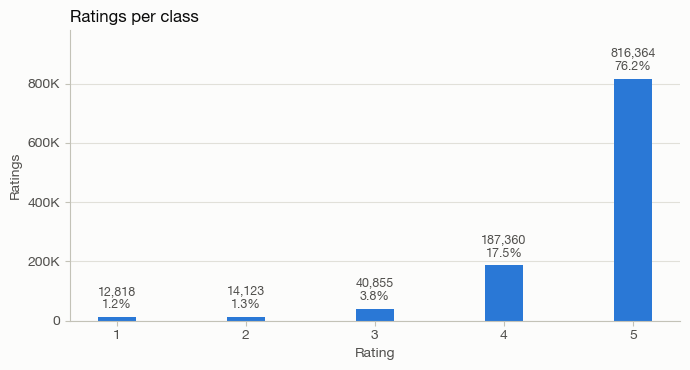

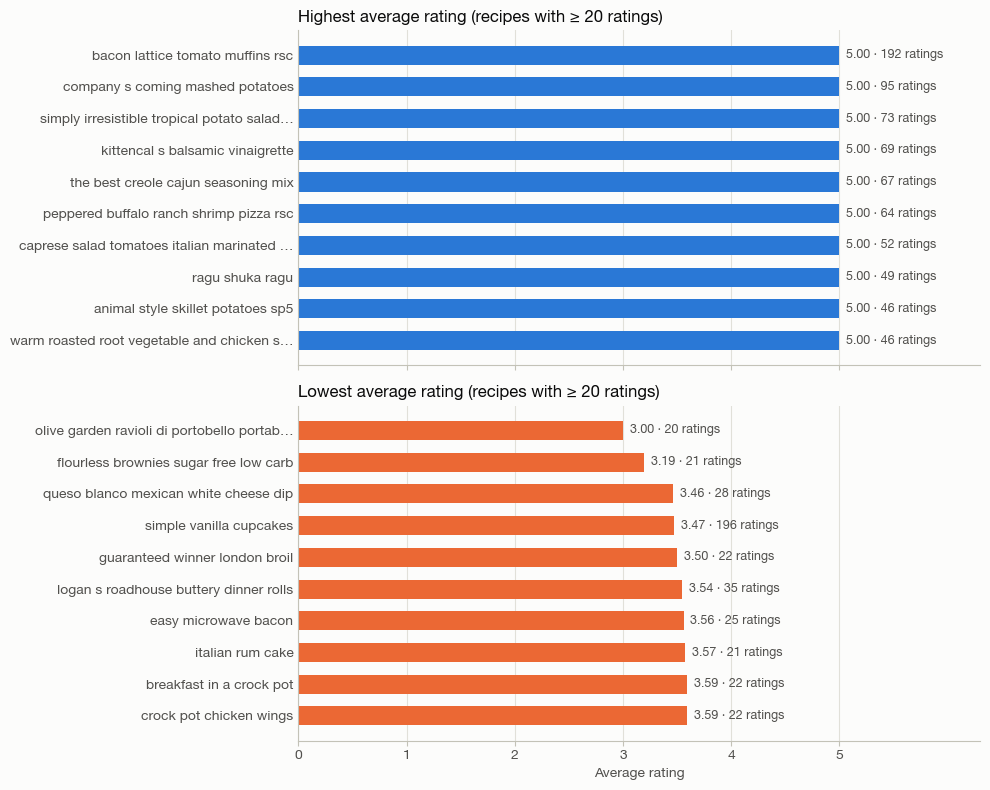

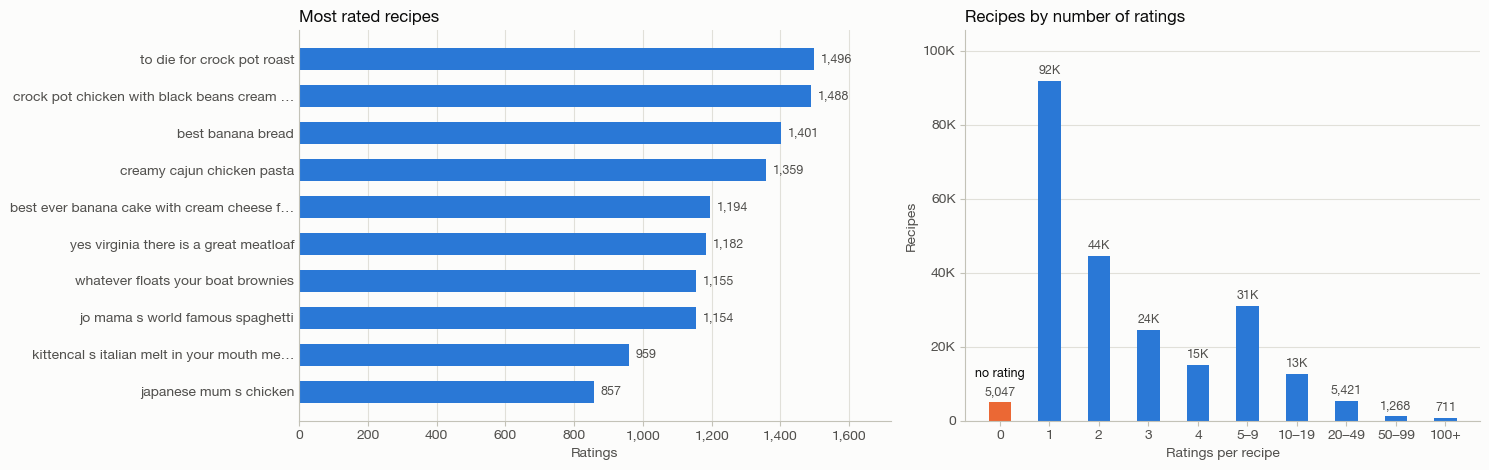

5,047 of 231,637 recipes (2.2%) have no rating; 91,698 have exactly one.


,recipe_id,name,rating_count,average_rating
least rated,,,,
0,164100,1 2 3 hash browns pie k,0,NaN
1,471666,1 2 3 swiss meringue buttercream,0,NaN
2,533190,1 minute breakfast sandwich,0,NaN
3,459738,1 point plus hg s faux fried pickles,0,NaN
4,472955,14 day pickles,0,NaN
5,525649,15 bean soup in the instant pot,0,NaN
6,246548,15 minute italian chicken rice with vegetables,0,NaN
7,531148,15 minute shrimp stir fry,0,NaN
8,282812,15 minutes oatmeal rice cooker,0,NaN


In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MIN_RATINGS_FOR_AVERAGE = 20
TOP_N = 10
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}


def compact(value, _=None):
    return f"{value / 1e6:.1f}M" if value >= 1e6 else f"{value / 1e3:.0f}K" if value >= 1e4 else f"{value:,.0f}"


def short_name(name, width=42):
    name = " ".join(str(name).split())
    return name if len(name) <= width else name[:width - 1] + "…"


def ranked_bars(ax, frame, value, color, label, title):
    """Horizontal bars, first row on top, each labeled at its tip."""
    rows = frame.iloc[::-1]
    ax.barh(range(len(rows)), rows[value], height=0.6, color=color)
    ax.set_yticks(range(len(rows)), [short_name(name) for name in rows["name"]])
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    for y, (_, row) in enumerate(rows.iterrows()):
        ax.annotate(label(row), (row[value], y), xytext=(5, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_title(title)


recipe_stats = item_catalog[["recipe_id", "name"]].copy()
recipe_stats["name"] = recipe_stats["name"].map(lambda name: " ".join(str(name).split()))
per_recipe = observed_ratings.groupby("item_index")["rating"].agg(["size", "mean"]).reindex(range(len(item_catalog)))
recipe_stats["rating_count"] = per_recipe["size"].fillna(0).astype(np.int64).to_numpy()
recipe_stats["average_rating"] = per_recipe["mean"].to_numpy()

# 1. Ratings per class.
class_counts = observed_ratings["rating"].astype(int).value_counts().reindex(
    range(1, NUM_RATING_CLASSES + 1), fill_value=0)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(class_counts.index, class_counts, width=0.3, color=BLUE)
    for rating, count in class_counts.items():
        ax.annotate(f"{count:,}\n{count / class_counts.sum():.1%}", (rating, count), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(xticks=class_counts.index, xlabel="Rating", ylabel="Ratings", title="Ratings per class")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.2)
    fig.tight_layout()
    plt.show()

# 2. Highest and lowest average rating among recipes with enough ratings.
rated_enough = recipe_stats[recipe_stats["rating_count"] >= MIN_RATINGS_FOR_AVERAGE]
best_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[False, False]).head(TOP_N)
worst_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[True, False]).head(TOP_N)
average_label = lambda row: f"{row.average_rating:.2f} · {row.rating_count:,} ratings"
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ranked_bars(axes[0], best_rated, "average_rating", BLUE, average_label,
                f"Highest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    ranked_bars(axes[1], worst_rated, "average_rating", ORANGE, average_label,
                f"Lowest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    axes[1].set(xlim=(0, 6.3), xticks=range(6), xlabel="Average rating")
    fig.tight_layout()
    plt.show()

# 3. Most rated recipes, and recipes by number of ratings (0 = without a rating).
most_rated = recipe_stats.nlargest(TOP_N, "rating_count")
bucket_labels = ["0", "1", "2", "3", "4", "5–9", "10–19", "20–49", "50–99", "100+"]
buckets = pd.cut(recipe_stats["rating_count"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                 right=False, labels=bucket_labels).value_counts().reindex(bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
    ranked_bars(left, most_rated, "rating_count", BLUE, lambda row: f"{row.rating_count:,}", "Most rated recipes")
    left.set(xlim=(0, most_rated["rating_count"].max() * 1.15), xlabel="Ratings")
    left.xaxis.set_major_formatter(FuncFormatter(compact))
    right.bar(bucket_labels, buckets, width=0.45, color=[ORANGE] + [BLUE] * (len(bucket_labels) - 1))
    for x, count in enumerate(buckets):
        right.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                       ha="center", va="bottom", color=INK_2, fontsize=9)
    right.annotate("no rating", (0, buckets.iloc[0]), xytext=(0, 16), textcoords="offset points",
                   ha="center", va="bottom", color=INK, fontsize=9)
    right.set(title="Recipes by number of ratings", xlabel="Ratings per recipe", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    right.margins(y=0.15)
    fig.tight_layout()
    plt.show()

unrated = recipe_stats["rating_count"].eq(0)
print(f"{unrated.sum():,} of {len(recipe_stats):,} recipes ({unrated.mean():.1%}) have no rating; "
      f"{recipe_stats['rating_count'].eq(1).sum():,} have exactly one.")
least_rated = recipe_stats.sort_values(["rating_count", "name"], kind="stable").head(TOP_N)
display(least_rated.reset_index(drop=True).rename_axis("least rated"))

**Rating shares before and after rating-5 thinning**

Thinning changes training targets only, so this compares the training split before
thinning (`train_ratings`) with the thinned targets (`train_targets`). Validation and
user histories keep every rating. The plot reuses the style from the overview cell above.

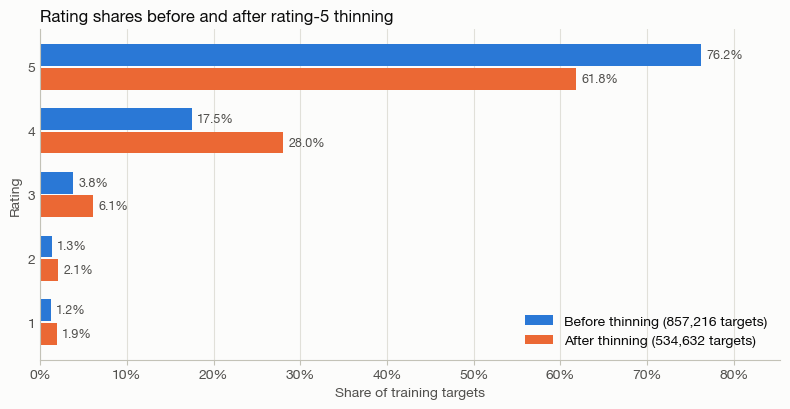

,before_count,before_percent,after_count,after_percent,change_points
rating,,,,,
1,10254,1.20,10254,1.92,0.72
2,11299,1.32,11299,2.11,0.80
3,32684,3.81,32684,6.11,2.30
4,149888,17.49,149888,28.04,10.55
5,653091,76.19,330507,61.82,-14.37


In [7]:
from matplotlib.ticker import PercentFormatter

counts = {when: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
          for when, frame in [("before", train_ratings), ("after", train_targets)]}
thinning_shares = pd.DataFrame({
    "before_count": counts["before"], "before_percent": 100 * counts["before"] / counts["before"].sum(),
    "after_count": counts["after"], "after_percent": 100 * counts["after"] / counts["after"].sum(),
})
thinning_shares["change_points"] = thinning_shares["after_percent"] - thinning_shares["before_percent"]

bar_height, bar_gap = 0.34, 0.03
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for when, color, direction in [("before", BLUE, 1), ("after", ORANGE, -1)]:
        positions = rating_levels + direction * (bar_height + bar_gap) / 2
        shares = thinning_shares[f"{when}_percent"]
        ax.barh(positions, shares, height=bar_height, color=color,
                label=f"{when.capitalize()} thinning ({counts[when].sum():,} targets)")
        for position, share in zip(positions, shares):
            ax.annotate(f"{share:.1f}%", (share, position), xytext=(4, 0), textcoords="offset points",
                        va="center", color=INK_2, fontsize=9)
    ax.set(yticks=rating_levels, xlabel="Share of training targets", ylabel="Rating",
           xlim=(0, thinning_shares[["before_percent", "after_percent"]].to_numpy().max() * 1.12),
           title="Rating shares before and after rating-5 thinning")
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    plt.show()
display(thinning_shares.round(2))

**Ratings per user**

How much history each user has, before and after the split and rating-5 thinning. The user
tower (GRU + user-ID embedding) can only learn a user's taste from these ratings.

,users,ratings,mean,median,p75,p90,p99,max,share_with_1,share_with_5_or_fewer
observed,196098.0,1071520.0,5.464,1.0,2.0,5.0,68.0,7665.0,0.716,0.904
train_history,167333.0,857216.0,5.123,1.0,2.0,5.0,64.0,6123.0,0.717,0.905
train_targets,167328.0,534632.0,3.195,1.0,2.0,5.0,31.0,2076.0,0.717,0.922
validation,61541.0,214304.0,3.482,1.0,2.0,4.0,45.0,1542.0,0.724,0.920


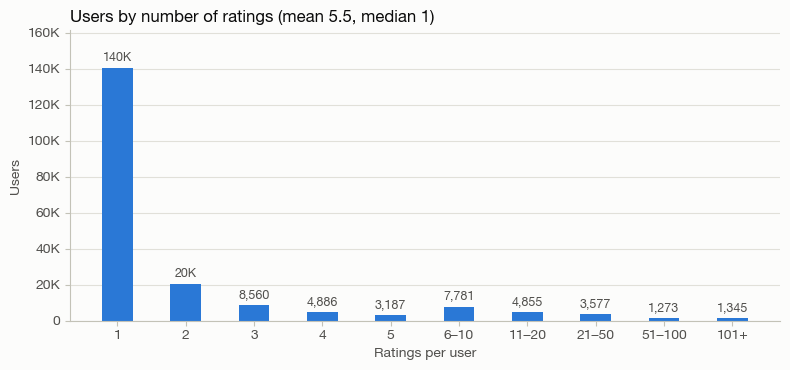

In [8]:
per_user = {name: frame.groupby("user_id").size()
            for name, frame in [("observed", observed_ratings), ("train_history", train_ratings),
                                ("train_targets", train_targets), ("validation", validation_ratings)]}
user_summary = pd.DataFrame({
    name: {"users": len(counts), "ratings": int(counts.sum()), "mean": counts.mean(), "median": counts.median(),
           "p75": counts.quantile(0.75), "p90": counts.quantile(0.90), "p99": counts.quantile(0.99),
           "max": counts.max(), "share_with_1": (counts == 1).mean(), "share_with_5_or_fewer": (counts <= 5).mean()}
    for name, counts in per_user.items()
}).T
display(user_summary.round(3))

user_bucket_labels = ["1", "2", "3", "4", "5", "6–10", "11–20", "21–50", "51–100", "101+"]
user_buckets = pd.cut(per_user["observed"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                      labels=user_bucket_labels).value_counts().reindex(user_bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.bar(user_bucket_labels, user_buckets, width=0.45, color=BLUE)
    for x, count in enumerate(user_buckets):
        ax.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(title=f"Users by number of ratings (mean {per_user['observed'].mean():.1f}, "
                 f"median {per_user['observed'].median():.0f})",
           xlabel="Ratings per user", ylabel="Users")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.15)
    fig.tight_layout()
    plt.show()

**Frozen phrase semantics and nutrition clusters**

Each distinct phrase is encoded once by the pinned BERT checkpoint. Padding and special
tokens are excluded from mean pooling. A shared SVD compresses the frozen phrase vectors;
then each recipe separately mean-pools its ingredient, adjective, and verb phrases.
These three vectors and field-presence indicators remain separate item inputs.

Content preprocessing uses the complete recipe catalog, including unrated recipes, but
never reads user IDs, ratings, or dates. Validation therefore measures held-out ratings for
a known catalog, not a future-catalog cold-start scenario. Nutrition clusters use scaled
per-recipe nutrient means, and the displayed cluster means count each recipe once.

References: [BERT](https://huggingface.co/docs/transformers/model_doc/bert) and
[MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html).

In [9]:
semantic_features, semantic_preprocessing = encode_semantic_fields(
    item_catalog, CACHE_DIR, device, model_name=BERT_MODEL, revision=BERT_REVISION,
    batch_size=BERT_BATCH_SIZE, max_length=BERT_MAX_LENGTH,
    semantic_dim=SEMANTIC_DIM_PER_FIELD, seed=RANDOM_STATE
)
numeric_features, nutrition_cluster_means, numeric_preprocessing = build_numeric_features(
    item_catalog, n_clusters=NUTRITION_CLUSTERS, seed=RANDOM_STATE
)
item_features = np.concatenate([semantic_features, numeric_features], axis=1).astype(np.float32)
del semantic_features, numeric_features
assert np.isfinite(item_features).all()
print(f"Item feature matrix: {item_features.shape}; {item_features.nbytes / 2**20:.1f} MiB")
display(nutrition_cluster_means)
display(item_catalog[["recipe_id", "name", "nutrition_cluster", "price_total_known",
                      "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]].head())

Item feature matrix: (231637, 444); 392.3 MiB


,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g)
nutrition_cluster,,,,,,,
0,2.152044e+06,6432.775895,2150.086373,184857.085908,5215.042190,2455.867384,6883.037672
1,1.794072e+05,14.454691,1610.445114,62501.720163,292.161731,1.017911,1725.305905
2,3.706258e+05,904.587372,525.764180,45218.741756,781.077594,310.692206,1653.948500
3,1.584559e+04,1.338235,64.779412,248089.411765,25.367647,0.411765,3.970588
4,5.626292e+05,15.244529,9907.322345,0.000000,170.008106,0.210754,5989.219130
5,1.614268e+05,396.399732,415.231388,29878.470825,257.679410,128.158283,694.406439
6,1.690281e+05,576.911218,138.818722,18340.564636,531.277860,224.621100,0.000000
7,6.959220e+05,1595.325660,5663.159326,28914.990031,532.517673,681.002961,4538.462933
8,1.269593e+06,4574.103774,0.000000,77238.896952,2912.264151,1493.759071,2365.602322


,recipe_id,name,nutrition_cluster,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper
0,137739,arriba baked winter squash mexican style,26,38.83,3,6.0,32.83,44.83
1,31490,a bit different breakfast pizza,17,25.95,2,4.0,21.95,29.95
2,112140,all in the kitchen chili,10,58.35,5,10.0,48.35,68.35
3,59389,alouette potatoes,10,32.77,6,12.0,20.77,44.77
4,44061,amish tomato ketchup for canning,29,30.35,4,8.0,22.35,38.35


**Stratified validation, history-only profiles, and recent ratings weighted more heavily**

Ratings 1–5 are observed labels; 0 and missing ratings are unrated. Missing or invalid
dates on observed ratings raise an error. Repeated user–recipe ratings keep their latest
event. Validation is a random 20% holdout **stratified on the rating** (scikit-learn
`train_test_split(..., stratify=y)`), so training and validation have the same share of
each rating 1–5. The holdout is random, not the newest ratings: the model can train on
ratings dated after some validation ratings. Validation therefore measures how well the
model fills in missing ratings, not how well it predicts future ones, and it may score
better than a time-based holdout would.

For every target, the user tower sees **only strictly earlier training ratings**, with the
target recipe excluded. Same-day events have no known order, so none can reveal another
same-day target. Validation ratings never enter training histories or validation histories.

**User tower.** The GRU reads up to 64 of the most recent earlier ratings, oldest first.
Each step sees the recipe's content features, a learned embedding of its rating, a
one-hot of its `level` (negative 1–2, neutral 3, positive 4–5), and
`log(1 + days before the target)`. Attention pools the GRU outputs. Each rating's score
starts with a recency prior of `−days × ln 2 / RECENCY_HALF_LIFE_DAYS`, so a rating 180 days
older gets half the weight, and a neutral rating starts at `NEUTRAL_HISTORY_WEIGHT = 0.5` of
the weight of an equally old positive or negative rating. Training can adjust both priors.
The last GRU state, the pooled state, the history size, and the user-ID embedding feed the
user MLP. With no history, the GRU summaries are zero and the ID embedding still applies.
The ID embedding has one row per training user plus row 0 for unknown users. In training,
`USER_ID_DROPOUT = 0.1` of rows use row 0 instead of the real ID, so row 0 learns a sensible
default.

**Item tower.** Content features (ingredient, adjective and verb semantics; nutrition
clusters; price) are concatenated with a learned **recipe-ID embedding** (`ITEM_ID_DIM`)
before the MLP. Recipes with at least `MIN_ITEM_RATINGS_FOR_ID = 5` training positives get
their own ID row; all others share row 0, a zero PAD row, and rely on content alone (cold
start). In training, `ITEM_ID_DROPOUT = 0.1` of recipe IDs fall back to row 0, so the content
path keeps learning. Both towers are L2-normalized (`NORMALIZE_EMBEDDINGS`).

**The two-tower retrieves; it never predicts a rating.** Rating predictions, P(rating 1–5),
and class balancing belong to the LightGBM reranker (`model_training_reranker.ipynb`).

**Rating-5 thinning (training targets only).** About 76% of observed ratings are 5, and some
users give almost nothing else. Each rating-5 target is kept with probability
`min(1, limit / user's 5s)`, where `limit = max(5, 1.0 × user's other ratings)`
(`MAX_FIVE_STAR_TARGETS_PER_USER`, `MAX_FIVE_TO_OTHER_RATIO`). Validation keeps the real
rating distribution, and user histories keep every training rating.

**Training rows.** One row per positive (4–5★) training rating; 3★ ratings are not rows,
and 1–2★ recipes are hard negatives. Each epoch uses at most `MAX_ROWS_PER_USER = 50` random
rows per user, resampled every epoch, so heavy users don't dominate but all their rows get
used over time. Each row carries one hard negative, a random 1–2★ recipe from the same
user's training ratings (redrawn every epoch), or PAD (−1) if the user has none. The target
and its hard negative are both hidden from the row's history. Training rows also carry a
recency weight relative to the **training-only** latest date (0.1 floor).

**Mask.** `HistoryDataset.collate` builds a `[B, 2B]` boolean mask on the CPU. For each row,
masked cells count as neither positive nor negative:

| Masked when the column is… | Why |
|---|---|
| another positive of the row's user (from all their ratings, including a duplicate of the row's own recipe) | it would be a false negative |
| a neutral (3★) recipe of the row's user | neither liked nor disliked |
| PAD | an empty hard-negative slot |

Never masked: the diagonal (the row's own positive) and the user's own dislikes.

**Loss.** `logits = [U·Iᵀ | U·Hᵀ] / τ`, with `τ = IN_BATCH_TEMPERATURE = 0.05`. The labels are
the diagonal of the left block, masked cells are set to −∞, and the loss is cross-entropy.
The in-batch (left) block subtracts `log q`, each recipe's add-one smoothed share of training
positives, because batches sample positives by popularity. The hard-negative (right) block
adds `log w` (`HARD_NEGATIVE_WEIGHT`). As noted above, `log q` is centered within each batch
first: the correction only needs the differences between in-batch columns, and uncentered it
would shift the whole left block about +10 above the hard negatives, which then never matter.

**Evaluation.** The validation in-batch loss uses the same masks (keys from training and
validation ratings) and picks the best epoch. After each epoch, **Recall@K** is measured on
`RECALL_SAMPLE_USERS` sampled validation users; after training, it is measured on every
validation user with training history, next to a popularity baseline (the most-rated recipes).
`hard_negative_accuracy` is how often a positive outscores its own hard negative (0.5 is
chance).

References: [sampling-bias-corrected in-batch softmax (logQ)](https://research.google/pubs/sampling-bias-corrected-neural-modeling-for-large-corpus-item-recommendations/),
and [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [10]:
# Training rows: one per liked (4-5 star) rating, each with one same-user 1-2 star hard negative
# or PAD. Histories keep every training rating (all levels).
user_lookup = build_user_lookup(train_ratings)
train_positive_targets = positive_rows(train_targets)
validation_positive_targets = positive_rows(validation_ratings)
train_dataset = HistoryDataset(
    train_positive_targets, train_ratings, user_lookup, max_history=MAX_HISTORY,
    half_life_days=RECENCY_HALF_LIFE_DAYS, training=True, contrast_pool=train_ratings, seed=RANDOM_STATE
)
# Validation hard negatives come from held-out validation ratings only; its mask sees training + validation.
validation_dataset = HistoryDataset(
    validation_positive_targets, train_ratings, user_lookup, max_history=MAX_HISTORY,
    half_life_days=RECENCY_HALF_LIFE_DAYS, training=False, contrast_pool=validation_ratings, seed=RANDOM_STATE
)
item_id_rows, num_item_ids = build_item_id_rows(train_positive_targets["item_index"], len(item_catalog),
                                                MIN_ITEM_RATINGS_FOR_ID)
epoch_rows = len(train_dataset.resample(MAX_ROWS_PER_USER, RANDOM_STATE))
recall_sample = RecallAtK(train_ratings, validation_positive_targets, user_lookup, len(item_catalog),
                          ks=RECALL_KS, max_history=MAX_HISTORY, sample_users=RECALL_SAMPLE_USERS, seed=RANDOM_STATE)
print(f"{len(user_lookup):,} training users; {(validation_dataset.user_indices > 0).mean():.1%} of "
      "validation rows come from users seen in training")
print(f"Positive rows: {len(train_dataset.targets):,} training ({epoch_rows:,} per epoch with at most "
      f"{MAX_ROWS_PER_USER} per user), {len(validation_dataset):,} validation; "
      f"{len(train_targets) - len(train_dataset.targets):,} neutral/negative training targets are not rows")
print(f"Rows with a hard negative: {train_dataset.has_contrast.mean():.1%} training, "
      f"{validation_dataset.has_contrast.mean():.1%} validation; the rest use PAD")
print(f"{num_item_ids:,} of {len(item_catalog):,} recipes have at least {MIN_ITEM_RATINGS_FOR_ID} training "
      "positives and get their own ID embedding; the rest use content features only")
print(f"Recall@K after each epoch: {len(recall_sample.users):,} sampled validation users")

167,333 training users; 86.8% of validation rows come from users seen in training
Positive rows: 480,395 training (370,602 per epoch with at most 50 per user), 200,745 validation; 54,237 neutral/negative training targets are not rows
Rows with a hard negative: 34.6% training, 19.5% validation; the rest use PAD
19,620 of 231,637 recipes have at least 5 training positives and get their own ID embedding; the rest use content features only
Recall@K after each epoch: 10,000 sampled validation users


**From ratings to one training batch**

1. **Split by rating** per user: 4–5★ ratings are positives (training rows), 1–2★ recipes are
   hard negatives, and 3★ recipes are neutral: never a row, and masked as columns.
2. **Rows:** one per positive (at most `MAX_ROWS_PER_USER` per user per epoch, resampled),
   each with one random hard negative from the same user, or `PAD` (−1).
3. **Batch tensors:** `U` users, `I` their positives, `H` their hard negatives.
4. **Logits `[B × 2B]`:** every user against `[I, H]`; row `i`'s label is column `i` (P). Other
   columns are in-batch negatives (N) or hard negatives (HN, including other users'
   dislikes). Masked: another positive or a neutral recipe of the row's user, and PAD.

The cell below shows these steps on real rows. Its batch puts three rows of one user
together, so their positives mask each other ("mask: liked").

In [11]:
# 1-2. Split by rating for a few users who have liked, neutral and disliked recipes.
level_counts = (train_ratings.groupby(["user_id", "level"]).size().unstack(fill_value=0)
                .reindex(columns=LEVEL_NAMES, fill_value=0))
example_users = level_counts[(level_counts["negative"] > 0) & (level_counts["neutral"] > 0)
                             & (level_counts["positive"] >= 3)].index[:5]
example_split = (train_ratings[train_ratings.user_id.isin(example_users)]
                 .assign(recipe=lambda frame: frame.item_index.map(item_catalog["name"].str.slice(0, 30)))
                 .groupby(["user_id", "level"])["recipe"].apply(list).unstack().reindex(columns=LEVEL_NAMES))
display(example_split)

# 3-4. A real batch from HistoryDataset.collate: three rows of one user plus five other rows.
example_rng = np.random.default_rng(RANDOM_STATE)
active_users = train_dataset.targets["user_id"].to_numpy()[train_dataset.active]
own_positions = np.flatnonzero(active_users == example_users[0])[:3]
other_positions = example_rng.choice(np.flatnonzero(active_users != example_users[0]), 8 - len(own_positions),
                                     replace=False)
example_batch = train_dataset.collate([train_dataset[int(position)]
                                       for position in np.concatenate([own_positions, other_positions])])
print("U =", example_batch["user_index"].tolist())
print("I =", example_batch["item_index"].tolist())
print("H =", example_batch["hard_item_index"].tolist(), "  (-1 = PAD)")
example_roles = train_dataset.batch_roles(example_batch["row"].numpy(), example_batch["item_index"].numpy(),
                                          example_batch["hard_item_index"].numpy())
display(pd.DataFrame(np.array(BATCH_ROLES, dtype=object)[example_roles],
                     index=[f"u{user}" for user in example_batch["user_index"].tolist()],
                     columns=[f"I:{item}" for item in example_batch["item_index"].tolist()]
                     + [f"H:{'PAD' if item == PAD_ITEM else item}" for item in example_batch["hard_item_index"].tolist()]))

level,negative,neutral,positive
user_id,,,
100026,[english monkey breakfast snac],[golden chicken and autumn vege],"[sweet potato bake with shredde, mild or hot a..."
100147,"[deb s beefy mac, spicy sweet mustard chicken,...","[chicken with sun dried tomato , favorite gril...","[steak and ale meat marinade, angie s awesome ..."
100149,"[maduros en gloria, creamy garlic chicken]","[dad s casserole, the bombdiggity chicken]","[blackberry cake, blt bites, sour cream salsa ..."
1001924,"[kat s slow cooker lasagna, to die for crock p...",[hawaiian slow cooker chicken],"[crock pot chicken with black b, slow cook dow..."
100225,[olive garden garlic alfredo sa],[quick yellow cake],"[microwave baked apples w min, pork tenderlo..."


U = [14, 14, 14, 138293, 95953, 125048, 13520, 95080]
I = [206379, 135609, 36365, 190695, 147226, 22478, 185911, 195895]
H = [80726, 80726, 80726, -1, 201074, 220035, -1, -1]   (-1 = PAD)


,I:206379,I:135609,I:36365,I:190695,I:147226,I:22478,I:185911,I:195895,H:80726,H:80726,H:80726,H:PAD,H:201074,H:220035,H:PAD,H:PAD
u14,P,mask: liked,mask: liked,N,N,N,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u14,mask: liked,P,mask: liked,N,N,N,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u14,mask: liked,mask: liked,P,N,N,N,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u138293,N,N,N,P,N,N,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u95953,N,N,mask: liked,N,P,N,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u125048,N,N,N,N,N,P,N,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u13520,N,N,N,N,N,N,P,N,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD
u95080,N,N,N,N,N,N,N,P,HN,HN,HN,mask: PAD,HN,HN,mask: PAD,mask: PAD


**Class distribution in each training batch**

One epoch as `train_two_tower` builds it: at most `MAX_ROWS_PER_USER` rows per user, shuffled,
full batches of `BATCH_SIZE` (the last partial batch is dropped), and one hard-negative draw
per row. For each batch: rows rated 4 vs 5, hard negatives rated 1 vs 2 or PAD, and (for the
first 200 batches) how many logits are masked because they hold another liked recipe of the
row's user, a neutral recipe of that user, or PAD.

723 batches of 512 rows (426 rows dropped as the last partial batch); logits per batch: 512 x 1024


,rows,positive_4,positive_5,hard_negative_1,hard_negative_2,hard_negative_pad,masked_liked,masked_neutral,masked_pad
mean,512.0,134.7,377.3,34.3,82.2,395.5,777.5,39.5,202391.0
std,0.0,10.2,10.2,5.5,8.2,9.3,101.7,10.8,4898.8
min,512.0,105.0,340.0,16.0,57.0,363.0,553.0,16.0,187392.0
50%,512.0,134.0,378.0,34.0,82.0,396.0,780.0,38.5,202240.0
max,512.0,172.0,407.0,53.0,110.0,420.0,1056.0,70.0,213504.0


,rows,positive_4,positive_5,hard_negative_1,hard_negative_2,hard_negative_pad,masked_liked,masked_neutral,masked_pad
batch,,,,,,,,,
0,512,109,403,26,84,402,699.0,20.0,205824.0
1,512,150,362,31,75,406,791.0,37.0,207872.0
2,512,124,388,47,79,386,775.0,31.0,197632.0
3,512,137,375,35,78,399,807.0,37.0,204288.0
4,512,131,381,37,65,410,658.0,25.0,209920.0
5,512,130,382,40,75,397,699.0,27.0,203264.0
6,512,144,368,32,101,379,840.0,57.0,194048.0
7,512,137,375,33,72,407,747.0,26.0,208384.0
8,512,133,379,25,88,399,909.0,42.0,204288.0


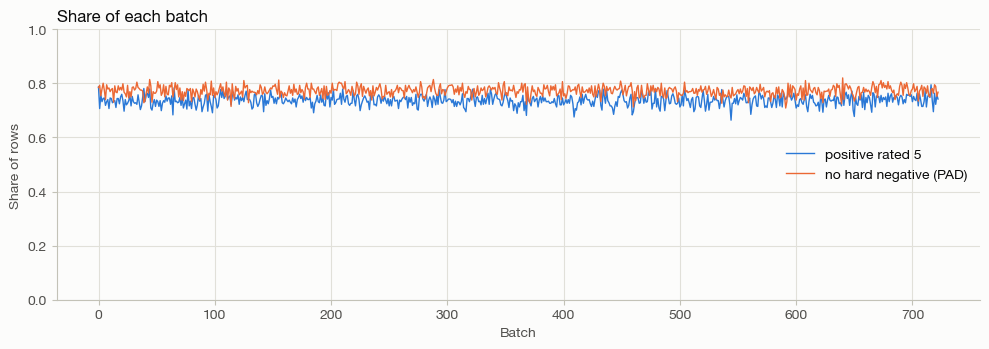

In [12]:
# Labels only, so a full epoch takes seconds instead of building every row's history.
train_dataset.resample(MAX_ROWS_PER_USER, RANDOM_STATE)
draw_rng = np.random.default_rng(RANDOM_STATE)
epoch_positions = train_dataset.active[draw_rng.permutation(len(train_dataset))]
epoch_users = train_dataset.targets["user_id"].to_numpy()[epoch_positions]
epoch_ratings = train_dataset.targets["rating"].to_numpy()[epoch_positions].astype(int)
epoch_positives = train_dataset.targets["item_index"].to_numpy()[epoch_positions]
# One hard-negative draw per row, the same way HistoryDataset draws them during training.
epoch_hard = np.array([item if sign > 0 else PAD_ITEM for item, sign in
                       (train_dataset._contrast(POSITIVE, user, draw_rng) for user in epoch_users)])
pool_ratings = dict(zip(zip(train_ratings.user_id, train_ratings.item_index), train_ratings.rating.astype(int)))
hard_ratings = np.array([0 if item == PAD_ITEM else pool_ratings[(user, item)]
                         for user, item in zip(epoch_users, epoch_hard)])
batch_count = len(epoch_positions) // BATCH_SIZE  # drop_last, like training
batch_ids = np.arange(batch_count * BATCH_SIZE) // BATCH_SIZE
used = slice(0, batch_count * BATCH_SIZE)
batch_classes = pd.DataFrame({
    "rows": pd.Series(batch_ids).value_counts().sort_index(),
    **{f"positive_{r}": pd.Series(batch_ids[epoch_ratings[used] == r]).value_counts() for r in (4, 5)},
    **{f"hard_negative_{r}": pd.Series(batch_ids[hard_ratings[used] == r]).value_counts() for r in (1, 2)},
    "hard_negative_pad": pd.Series(batch_ids[hard_ratings[used] == 0]).value_counts(),
}).fillna(0).astype(int).rename_axis("batch")
masked_cells = []
for batch in range(min(batch_count, 200)):
    rows = slice(batch * BATCH_SIZE, (batch + 1) * BATCH_SIZE)
    roles = train_dataset.batch_roles(epoch_positions[rows], epoch_positives[rows], epoch_hard[rows])
    masked_cells.append({name: int((roles == code).sum()) for code, name in
                         [(ROLE_LIKED, "masked_liked"), (ROLE_NEUTRAL, "masked_neutral"), (ROLE_PAD, "masked_pad")]})
batch_classes = batch_classes.join(pd.DataFrame(masked_cells).rename_axis("batch"))
print(f"{batch_count:,} batches of {BATCH_SIZE} rows ({len(epoch_positions) - batch_count * BATCH_SIZE:,} rows "
      f"dropped as the last partial batch); logits per batch: {BATCH_SIZE} x {2 * BATCH_SIZE}")
display(batch_classes.describe().loc[["mean", "std", "min", "50%", "max"]].round(1))
display(batch_classes.head(10))
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(10, 3.6))
    shares = batch_classes[["positive_5", "hard_negative_pad"]].div(batch_classes["rows"], axis=0)
    ax.plot(shares.index, shares["positive_5"], color=BLUE, linewidth=1, label="positive rated 5")
    ax.plot(shares.index, shares["hard_negative_pad"], color=ORANGE, linewidth=1, label="no hard negative (PAD)")
    ax.set(title="Share of each batch", xlabel="Batch", ylabel="Share of rows", ylim=(0, 1))
    ax.legend(frameon=False, loc="center right")
    fig.tight_layout()
    plt.show()

In [ ]:
recommendation_model = TwoTowerModel(
    feature_dim=item_features.shape[1], num_users=len(user_lookup), embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM, user_id_dim=USER_ID_DIM, half_life_days=RECENCY_HALF_LIFE_DAYS,
    user_id_dropout=USER_ID_DROPOUT, neutral_weight=NEUTRAL_HISTORY_WEIGHT, num_items=len(item_catalog),
    num_item_ids=num_item_ids, item_id_dim=ITEM_ID_DIM, item_id_dropout=ITEM_ID_DROPOUT,
    normalize=NORMALIZE_EMBEDDINGS
).set_item_id_rows(item_id_rows)
print(recommendation_model)
recommendation_model, training_history, validation_metrics = train_two_tower(
    recommendation_model, train_dataset, validation_dataset, item_features,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, device=device,
    patience=EARLY_STOPPING_PATIENCE, in_batch_temperature=IN_BATCH_TEMPERATURE,
    hard_negative_weight=HARD_NEGATIVE_WEIGHT, max_rows_per_user=MAX_ROWS_PER_USER,
    num_workers=NUM_WORKERS, recall_evaluator=recall_sample, seed=RANDOM_STATE
)
# In-batch loss per epoch, and Recall@K on the sampled validation users; the full history is saved.
display(training_history[["epoch", "train_rows", "train_in_batch_cross_entropy", "validation_in_batch_cross_entropy",
                          "validation_in_batch_relative", *[f"validation_recall@{k}" for k in RECALL_KS]]])
print(f"Kept validation in-batch cross-entropy: {validation_metrics['in_batch_cross_entropy']:.4f}")

TwoTowerModel(
  (item_embedding): Embedding(19621, 32, padding_idx=0)
  (item_tower): Sequential(
    (0): Linear(in_features=476, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (user_embedding): Embedding(167334, 32)
  (history_projection): Sequential(
    (0): Linear(in_features=444, out_features=128, bias=True)
    (1): ReLU()
  )
  (rating_embedding): Embedding(5, 16)
  (history_rnn): GRU(148, 128, batch_first=True)
  (history_attention): Linear(in_features=128, out_features=1, bias=True)
  (user_head): Sequential(
    (0): Linear(in_features=290, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
)
Epoch 01: in-batch CE train=6.7093 (370,176 rows, 0.968 of ln 2B), validation=6.6256 (0.956 of ln 2B); positive beat

**Recall@K against a popularity baseline**

For every validation user with training history: embed the user from all their training
ratings, recommend the top K recipes they haven't rated in training, and count how many of
their held-out validation positives (4–5★) appear. The baseline always recommends the
most-rated recipes, with the same exclusions. If the two-tower doesn't beat it, check the
data, τ, and batch size before anything else.

In [ ]:
recall_all = RecallAtK(train_ratings, validation_positive_targets, user_lookup, len(item_catalog),
                       ks=RECALL_KS, max_history=MAX_HISTORY)
most_rated = np.bincount(train_ratings["item_index"], minlength=len(item_catalog))
recall_report = pd.DataFrame({"two_tower": recall_all.evaluate(recommendation_model, item_features, device),
                              "popularity": recall_all.popularity(most_rated, device=device)})
display(recall_report)

**Recommend unseen recipes**

After validation is measured, serving may use all genuinely observed ratings. The example
uses a cutoff after the dataset's last interaction, appropriate for this historical data.
Set `as_of` explicitly to score from an earlier history; same-day/future ratings are excluded.
Pass `user_lookup` so a known user gets their ID embedding; unknown users use row 0.
Candidates with no ratings are still supported by item content. The `similarity` column is
the cosine similarity of the normalized towers (higher = closer), not a rating; P(rating 1–5)
comes from the reranker. The cell after next serves the same user from an item index.

In [ ]:
example_user_id = observed_ratings["user_id"].value_counts().index[0]
recommendations = recommend_recipes(
    recommendation_model, item_catalog, item_features, observed_ratings,
    user_id=example_user_id, user_lookup=user_lookup, top_k=20, max_history=MAX_HISTORY,
    as_of=observed_ratings["date"].max().floor("D") + pd.Timedelta(1, unit="D")
)
print(f"Recipe recommendations for user {example_user_id}")
display(recommendations)

Recipe recommendations for user 424680


,recipe_id,name,price_breakdown,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper,price_missing_fraction,price_all_missing,similarity
0,29679,reeses squares 5 ingredients no bake reese s,"{""milk chocolate chips"": 5.97, ""graham cracker...",22.17,2,4.0,18.17,26.17,0.400000,0,-0.338848
1,2886,best banana bread,"{""baking soda"": null, ""bananas"": 4.5, ""granula...",20.11,4,8.0,12.11,28.11,0.500000,0,-0.348853
2,32204,whatever floats your boat brownies,"{""miniature marshmallow"": null, ""chocolate chi...",36.98,8,16.0,20.98,52.98,0.571429,0,-0.356903
3,261889,kittencal s buttery cut out sugar cookies w i...,"{""baking soda"": null, ""light corn syrup"": null...",22.34,8,16.0,6.34,38.34,0.615385,0,-0.363084
4,97496,soft snickerdoodle cookies,"{""vanilla extract"": null, ""baking soda"": null,...",18.71,5,10.0,8.71,28.71,0.555556,0,-0.369051
5,205890,soft peanut butter cookies,"{""vanilla extract"": null, ""baking soda"": null,...",23.48,5,10.0,13.48,33.48,0.555556,0,-0.372289
6,31128,yummy crunchy apple pie,"{""pastry for single-crust pie"": null, ""butter""...",20.43,8,16.0,4.43,36.43,0.666667,0,-0.379934
7,100727,thick soft and chewy chocolate chip cookies,"{""baking soda"": null, ""nuts"": 12.3, ""shortenin...",26.14,6,12.0,14.14,38.14,0.600000,0,-0.392918
8,51104,peanut butter chocolate chip cookies,"{""baking soda"": null, ""granulated sugar"": null...",20.38,5,10.0,10.38,30.38,0.625000,0,-0.396180
9,50719,the sweetest blueberry muffins,"{""baking powder"": null, ""fresh blueberries"": 3...",23.19,6,12.0,11.19,35.19,0.545455,0,-0.397717


**Serving from an item index (FAISS)**

At inference the two-tower is just similarity: precompute every recipe vector, index them,
and query with the user vector. `ItemIndex` wraps a FAISS `IndexFlatIP` (exact inner product,
which is cosine here because the vectors are normalized), and `recommend_recipes(index=...)`
over-fetches by the number of recipes the user already rated, then filters them out. On
macOS it uses an exact torch scan instead, because FAISS and torch each bundle an OpenMP
runtime and loading both aborts the process. On Linux (Colab, Kaggle) FAISS is used when
installed (`pip install faiss-cpu`). `IndexFlatIP` suits up to about 1M recipes; beyond that,
switch to `IndexHNSWFlat` or `IndexIVFFlat`.

In [ ]:
serving_index = ItemIndex(encode_catalog(recommendation_model, item_features, device=device).numpy())
print(f"Item index: {serving_index.backend}, {len(serving_index.vectors):,} recipes x "
      f"{serving_index.vectors.shape[1]} dimensions")
indexed_recommendations = recommend_recipes(
    recommendation_model, item_catalog, item_features, observed_ratings,
    user_id=example_user_id, user_lookup=user_lookup, top_k=20, max_history=MAX_HISTORY,
    as_of=observed_ratings["date"].max().floor("D") + pd.Timedelta(1, unit="D"), index=serving_index
)
print("Same top 20 as scoring every recipe:",
      indexed_recommendations.recipe_id.tolist() == recommendations.recipe_id.tolist())
display(indexed_recommendations)

In [ ]:
old_recipe_data = pd.read_csv("input_stage2/price_mapped_nutrients.csv")

**Save the model together with its serving features**

The artifact directory contains both towers, the frozen preprocessing objects, ordered
recipe catalog and features, precomputed item vectors, observed histories, the user-ID
vocabulary (`user_vocabulary.csv`), and configuration. `item_vectors.npy` holds the normalized
recipe vectors an `ItemIndex` serves.
Keep them together: item index order must match across the catalog, arrays, and histories.
The reload example below uses the saved catalog directly and does not rerun BERT or clustering.

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_config = recommendation_model.config
torch.save({"state_dict": {key: value.detach().cpu() for key, value in recommendation_model.state_dict().items()},
            "model_config": model_config}, ARTIFACT_DIR / "two_tower.pt")
np.save(ARTIFACT_DIR / "item_features.npy", item_features, allow_pickle=False)
item_vectors = encode_catalog(recommendation_model, item_features, device=device)
np.save(ARTIFACT_DIR / "item_vectors.npy", item_vectors, allow_pickle=False)
serving_columns = ["recipe_id", "name", "nutrition_cluster", *NUTRITION_COLUMNS,
                   "price_total_known", "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]
item_catalog[serving_columns].to_csv(ARTIFACT_DIR / "catalog.csv", index=False)
observed_ratings.to_csv(ARTIFACT_DIR / "observed_ratings.csv", index=False)
pd.DataFrame({"user_id": list(user_lookup), "user_index": list(user_lookup.values())}).to_csv(
    ARTIFACT_DIR / "user_vocabulary.csv", index=False)
joblib.dump({"semantic": semantic_preprocessing, "numeric": numeric_preprocessing},
            ARTIFACT_DIR / "content_preprocessing.joblib")
config = {"format_version": "recipe_two_tower_v8", "model_config": model_config,
          "user_tower": "user_id_embedding_plus_gru_recency_attention",
          "item_tower": "content_features_plus_recipe_id_embedding", "similarity": "dot_product",
          "normalized_embeddings": NORMALIZE_EMBEDDINGS, "output": "dot_product_only",
          "loss": "in_batch_softmax_hard_negatives_masked_logq", "guide": "two-tower-implementation.md",
          "training_rows": "positive (4-5 star) only", "in_batch_temperature": IN_BATCH_TEMPERATURE,
          "hard_negative_weight": HARD_NEGATIVE_WEIGHT, "max_rows_per_user": MAX_ROWS_PER_USER,
          "min_item_ratings_for_id": MIN_ITEM_RATINGS_FOR_ID,
          "levels": {"negative": [1, 2], "neutral": [3], "positive": [4, 5]},
          "neutral_history_weight": NEUTRAL_HISTORY_WEIGHT,
          "validation_split": "stratified_random", "max_five_star_targets_per_user": MAX_FIVE_STAR_TARGETS_PER_USER,
          "max_five_to_other_ratio": MAX_FIVE_TO_OTHER_RATIO,
          "bert_model": BERT_MODEL, "bert_revision": BERT_REVISION,
          "recency_half_life_days": RECENCY_HALF_LIFE_DAYS, "max_history": MAX_HISTORY,
          "missing_price_error_dollars": MISSING_PRICE_ERROR_DOLLARS,
          "random_state": RANDOM_STATE, "validation_fraction": VALIDATION_FRACTION,
          "source_csv": str(DATA_PATH), "rating_min": 1.0, "rating_max": 5.0}
(ARTIFACT_DIR / "config.json").write_text(json.dumps(config, indent=2) + "\n")
training_history.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
print(f"Saved two-tower model and serving data to {ARTIFACT_DIR.resolve()}")

Saved two-tower model and serving data to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/two_tower
